# Analisis inicial del Challenge

Aqui quiero revisar inicialemente de manera completa y visual, como se comportan los datos del reto. Que entra que sale, una configuracion visual de que espera el modelo en cada tarea, ademas quieor verificar un ejemplo con la linea base como se comporta. Esto lo hago con la finalidad de entender el problema y ejecutarlo.

---

### Como usar este notebook

| Seccion | Que responde |
|---|---|
| **0. Entorno** | rutas, librerias, interruptores de ejecucion |
| **1. El reto** | reglas oficiales, contrato de salida, metricas *leidas del evaluador oficial* |
| **2. Datos de entrada y salida** | 3 ejemplos por tarea, formato, y cuanto de incompletos estan los datos |
| **3. Un ejemplo de punta a punta** | prompt exacto -> herramientas -> salida -> puntuacion descompuesta -> traza del grafo |
| **4. Resultados del baseline ya corrido** | los 238 casos etiquetados puntuados con el evaluador oficial |
| **5. Analisis del agente** | grafo, prompts, MCP, RAG, modelo, trazabilidad |
| **6. Cierre** | hallazgos y palancas, con la regla del reto que permite tocar cada cosa |

Tres interruptores en la celda de entorno controlan lo que se ejecuta de verdad:

- `EJECUTAR_MCP_EN_VIVO` — arranca el servidor MCP real y llama a las herramientas (segundos, sin GPU).
- `EJECUTAR_RAG_EN_VIVO` — arranca el servicio de embeddings y consulta la base de guias EAU (~30 s, CPU).
- `EJECUTAR_AGENTE_EN_VIVO` — carga el LLM en vLLM y corre **un** caso instrumentado (minutos, necesita la GPU). Por defecto **apagado**; la seccion 3.5 hace un *replay determinista* del mismo grafo sin LLM para que la traza se pueda leer siempre.

> Fuentes: repo local + [chimera-agent.grand-challenge.org](https://chimera-agent.grand-challenge.org/) (paginas *Challenge Rules*, *Data Sources and Imaging*, *EAU Guideline Use*) + el evaluador oficial `DIAGNijmegen/CHIMERA-agent`.

## 0. Entorno, rutas y utilidades

Todo el notebook trabaja sobre el repo **sin modificarlo**: solo lee `data/`, `test/output/`, el codigo fuente y
el evaluador oficial. Nada de lo que hay aqui escribe en el arbol del baseline (los volcados van a `delete/`).

In [61]:
# --- Librerias -------------------------------------------------------------
import json, os, sys, re, textwrap, inspect, warnings, collections, subprocess, asyncio
from pathlib import Path
from statistics import median

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image, JSON

# del stack del agente (se importan mas abajo, tras fijar sys.path)
# langgraph / langchain / mcp / hydra / jinja2 / pydantic
# sklearn solo para las matrices de confusion y la sonda de embeddings

warnings.filterwarnings('ignore')
%matplotlib inline

# --- Raiz del repo (el notebook vive en delete/) ----------------------------
def _buscar_raiz(p: Path) -> Path:
    for cand in [p, *p.parents]:
        if (cand / 'pyproject.toml').exists() and (cand / 'src' / 'chimera_agent_baseline').exists():
            return cand
    raise RuntimeError('No encuentro la raiz del repo chimera-agent-baseline')

REPO = _buscar_raiz(Path.cwd().resolve())
os.chdir(REPO)                        # las rutas del baseline son relativas a la raiz
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))
if str(REPO / 'dev') not in sys.path:
    sys.path.insert(0, str(REPO / 'dev'))

DATA   = REPO / 'data'                # inputs + ground_truth separados (ver nota abajo)
SALIDA = REPO / 'test' / 'output'     # predicciones del baseline ya corrido
EVAL_REPO = Path.home() / 'PycharmProjects' / 'CHIMERA-agent-eval'   # evaluador oficial clonado
VOLCADOS = REPO / 'delete'            # donde escribe este notebook (fuera del arbol del baseline)

# --- Interruptores ---------------------------------------------------------
EJECUTAR_MCP_EN_VIVO    = True    # arranca el servidor MCP y llama a las herramientas de verdad
EJECUTAR_RAG_EN_VIVO    = True    # arranca el servicio de embeddings y consulta las guias EAU
EJECUTAR_AGENTE_EN_VIVO = False   # carga el LLM (GPU) y corre un caso instrumentado
EJECUTAR_SONDA_EMBEDDINGS = True  # regresion rapida sobre los embeddings congelados (CPU, ~1 min)

# --- Estilo ----------------------------------------------------------------
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'figure.autolayout': True, 'axes.titlesize': 11})
PAL = {1: '#3b6ea5', 2: '#b3592e', 3: '#4c7a4c', 'gt': '#555555', 'pred': '#c0392b'}
pd.set_option('display.max_columns', 60, 'display.width', 200, 'display.max_colwidth', 90)

# --- Nombres de fichero por tarea (el contrato de Grand Challenge) ---------
FICHERO_PROMPT   = 'structured-prompt.json'
FICHERO_EMB      = 'prostate-modality-level-neural-representations.json'
FICHERO_CLINICO  = {1: 'prostate-biopsy-decision-clinical-data.json',
                    2: 'prostate-treatment-decision-clinical-data.json',
                    3: 'prostate-time-to-recurrence-or-last-follow-up-clinical-data.json'}
FICHERO_DECISION = {1: 'prostate-biopsy-decision.json',
                    2: 'prostate-treatment-decision.json',
                    3: 'prostate-time-to-recurrence-or-last-follow-up.json'}
FICHERO_RAZON    = {1: 'prostate-biopsy-decision-reasoning.json',
                    2: 'prostate-treatment-decision-reasoning.json',
                    3: 'prostate-time-to-recurrence-or-last-follow-up-reasoning.json'}
NOMBRE_TAREA = {1: 'T1 · decision de biopsia', 2: 'T2 · decision de tratamiento',
                3: 'T3 · tiempo a recurrencia bioquimica'}

# --- Utilidades de lectura -------------------------------------------------
def leer_json(p):
    p = Path(p)
    return json.loads(p.read_text()) if p.exists() else None

def casos(task, cuales='agent_input'):
    d = DATA / f'task{task}' / cuales
    return sorted(p.name for p in d.iterdir() if p.is_dir()) if d.is_dir() else []

def prompt_de(task, cid):   return leer_json(DATA / f'task{task}' / 'agent_input' / cid / FICHERO_PROMPT)
def clinico_de(task, cid):  return leer_json(DATA / f'task{task}' / 'agent_input' / cid / FICHERO_CLINICO[task])
def emb_bruto_de(task, cid):return leer_json(DATA / f'task{task}' / 'agent_input' / cid / FICHERO_EMB)

def gt_de(task, cid):
    base = DATA / f'task{task}' / 'ground_truth' / cid
    dec, raz = leer_json(base / FICHERO_DECISION[task]), leer_json(base / FICHERO_RAZON[task])
    if dec is None: return None
    return {'decision': dec, 'razonamiento': raz}

def pred_de(task, cid):
    base = SALIDA / f'task{task}' / cid
    dec, raz = leer_json(base / FICHERO_DECISION[task]), leer_json(base / FICHERO_RAZON[task])
    if dec is None: return None
    return {'decision': dec, 'razonamiento': raz}

# --- Utilidades de presentacion -------------------------------------------
def caja(titulo, ancho=100):
    print('\n' + '=' * ancho); print(titulo); print('=' * ancho)

def ver(obj, n=2600, titulo=None):
    # n=None imprime el objeto ENTERO, sin recortar.
    if titulo: caja(titulo)
    s = obj if isinstance(obj, str) else json.dumps(obj, indent=2, ensure_ascii=False)
    if n is None or len(s) <= n:
        print(s)
    else:
        print(s[:n] + f'\n... [recortado, {len(s)} caracteres en total]')

def envolver(texto, ancho=104, sangria=''):
    if texto is None: return '(null)'
    return '\n'.join(textwrap.fill(l, ancho, initial_indent=sangria, subsequent_indent=sangria) or sangria
                     for l in str(texto).splitlines())

print(f'REPO      {REPO}')
print(f'DATA      {DATA}          (existe: {DATA.is_dir()})')
print(f'SALIDA    {SALIDA}   (existe: {SALIDA.is_dir()})')
print(f'EVALUADOR {EVAL_REPO}    (existe: {(EVAL_REPO / "evaluation" / "evaluate.py").exists()})')
print(f'python    {sys.version.split()[0]}   ·   pandas {pd.__version__}   ·   numpy {np.__version__}')

REPO      /home/jjlondono/PycharmProjects/chimera-agent-baseline
DATA      /home/jjlondono/PycharmProjects/chimera-agent-baseline/data          (existe: True)
SALIDA    /home/jjlondono/PycharmProjects/chimera-agent-baseline/test/output   (existe: True)
EVALUADOR /home/jjlondono/PycharmProjects/CHIMERA-agent-eval    (existe: True)
python    3.12.3   ·   pandas 3.0.5   ·   numpy 2.3.5


In [62]:
# Inventario del repo: que pieza vive donde. Es el mapa que usa el resto del notebook.
piezas = [
    ('inference.py',                      'entrypoint del contenedor Grand Challenge (lee /input, escribe /output)'),
    ('src/chimera_agent_baseline/run.py', 'runner local con Hydra: recorre las tareas y persiste las salidas'),
    ('src/chimera_agent_baseline/agent/graph.py',    'grafo LangGraph: agent -> tools -> form_fill'),
    ('src/chimera_agent_baseline/agent/prompts.py',  'prompt de sistema (protocolo de coste de herramientas)'),
    ('src/chimera_agent_baseline/agent/form_fill.py','nodo terminal: prompt-and-parse contra el schema'),
    ('src/chimera_agent_baseline/output/schema.py',  'CONTRATO DEL RETO — intocable'),
    ('src/chimera_agent_baseline/mcp_server.py',     'servidor MCP stdio con el registro de herramientas'),
    ('src/chimera_agent_baseline/tools/definitions.py','ToolSpec por tarea (que campo del clinical-data revela cada tool)'),
    ('src/chimera_agent_baseline/tools/predictor.py', 'plantilla del predictor sobre embeddings (apagada)'),
    ('src/chimera_agent_baseline/features.py',        'FeatureStore de los embeddings congelados (no lo usa el baseline)'),
    ('src/chimera_agent_baseline/rag.py',             'RAG de guias: servicio de embeddings + ChromaDB'),
    ('src/chimera_agent_baseline/case_loader.py',     'renderiza structured-prompt.json con la plantilla Jinja'),
    ('templates/prompts/agent_prompt.j2',             'plantilla del prompt por caso'),
    ('configs/config.yaml',                           'configuracion Hydra por defecto'),
    ('dev/score_local.py',                            'puntuacion offline con el evaluador oficial'),
    ('dev/baseline_reference.json',                   'linea base medida (referencia para comparar)'),
]
inv = pd.DataFrame([{'ruta': r, 'existe': (REPO / r).exists(),
                     'lineas': len((REPO / r).read_text().splitlines()) if (REPO / r).exists() else 0,
                     'para que': d} for r, d in piezas])
display(inv.style.hide(axis='index'))

print('\nRecuento de casos por tarea')
cen = []
for t in (1, 2, 3):
    ci, cg, co = casos(t), casos(t, 'ground_truth'), sorted(p.name for p in (SALIDA / f'task{t}').iterdir()) if (SALIDA / f'task{t}').is_dir() else []
    cen.append({'tarea': t, 'casos en agent_input': len(ci), 'con ground_truth': len(cg),
                'sin etiqueta (≈test)': len(ci) - len(cg), 'con prediccion del baseline': len(co),
                'etiquetados SIN prediccion': len(set(cg) - set(co))})
display(pd.DataFrame(cen).style.hide(axis='index'))
print('Nota: inputs y etiquetas viven en carpetas separadas (agent_input/ vs ground_truth/) a proposito:')
print('      el CaseDataStore del servidor MCP indexa el directorio entero, asi que una etiqueta dentro')
print('      de agent_input/ seria visible para el agente a traves de una tool.')

ruta,existe,lineas,para que
inference.py,True,466,"entrypoint del contenedor Grand Challenge (lee /input, escribe /output)"
src/chimera_agent_baseline/run.py,True,243,runner local con Hydra: recorre las tareas y persiste las salidas
src/chimera_agent_baseline/agent/graph.py,True,99,grafo LangGraph: agent -> tools -> form_fill
src/chimera_agent_baseline/agent/prompts.py,True,99,prompt de sistema (protocolo de coste de herramientas)
src/chimera_agent_baseline/agent/form_fill.py,True,304,nodo terminal: prompt-and-parse contra el schema
src/chimera_agent_baseline/output/schema.py,True,239,CONTRATO DEL RETO — intocable
src/chimera_agent_baseline/mcp_server.py,True,179,servidor MCP stdio con el registro de herramientas
src/chimera_agent_baseline/tools/definitions.py,True,135,ToolSpec por tarea (que campo del clinical-data revela cada tool)
src/chimera_agent_baseline/tools/predictor.py,True,67,plantilla del predictor sobre embeddings (apagada)
src/chimera_agent_baseline/features.py,True,114,FeatureStore de los embeddings congelados (no lo usa el baseline)



Recuento de casos por tarea


tarea,casos en agent_input,con ground_truth,sin etiqueta (≈test),con prediccion del baseline,etiquetados SIN prediccion
1,195,91,104,194,1
2,153,72,81,153,0
3,75,75,0,73,2


Nota: inputs y etiquetas viven en carpetas separadas (agent_input/ vs ground_truth/) a proposito:
      el CaseDataStore del servidor MCP indexa el directorio entero, asi que una etiqueta dentro
      de agent_input/ seria visible para el agente a traves de una tool.


## 1. El reto: reglas, contrato y metricas

### 1.1 Las tres tareas

| | Tarea | Entrada clinica | Salida | Peso en el ranking |
|---|---|---|---|---|
| **T1** | Decision de biopsia (solo MRI) | informe mpMRI + variables clinicas | `"yes"` / `"no"` + razonamiento | **2** |
| **T2** | Estratificacion MRI + biopsia | MRI + patologia de biopsia + clinica | 1 de 4 acciones de manejo | **2** |
| **T3** | Pronostico tras prostatectomia | patologia quirurgica + biopsia + MRI + PSA | meses a recurrencia bioquimica + `event` | **1** |

El ranking global es la media ponderada **2 : 2 : 1** de los `ranking_score` de cada tarea.

### 1.2 Reglas oficiales que condicionan el diseno

De la pagina *Challenge Rules* del reto:

- **No se entrena desde cero**: se espera orquestar las herramientas y modelos provistos ("agent-level reasoning systems, not train models from scratch").
- **Datos y modelos externos permitidos** si son publicos y con licencia abierta (open-source / open-weight) que permita usarlos en la submision, y **declarados** en el nombre del algoritmo / pagina del algoritmo / publicacion.
- **Sin internet dentro del contenedor**: todas las dependencias y pesos van dentro de la imagen Docker.
- **Entregable**: contenedor Docker + manuscrito de 6 paginas (plantilla MICCAI Springer) + repo GitHub con licencia permisiva.
- **Equipos obligatorios** (aunque sean de una persona), sin cuentas duplicadas, sin participacion anonima en los leaderboards de validacion/test.
- **Embargo de publicacion** sobre resultados del training set hasta que salgan el paper del reto y el del baseline.

De la pagina *EAU Guideline Use*: se pueden usar recomendaciones seleccionadas de la **EAU Prostate Cancer Guidelines, edicion 2026** (y resumenes / reglas de decision derivadas) **solo** para investigacion no comercial dentro de CHIMERA-Agent, **sin redistribuir** el documento original ni porciones sustanciales, y **citando** la guia. Eso es exactamente lo que hay dentro de `resources/guidelines_db` (ChromaDB) — es decir, el RAG del baseline ya es un uso licenciado de la guia.

### 1.3 Herramientas que el reto nos da (y podemos reemplazar o extender)

| Recurso | Donde esta en el repo | Lo usa el baseline? |
|---|---|---|
| Variables clinicas estructuradas (edad, PSA, PI-RADS, DRE, prob. csPCa) | `structured-prompt.json` -> plantilla Jinja | **si**, van en el prompt |
| Documentos tipo EHR (informes, notas, labs, PSA, antecedentes) | `*-clinical-data.json` -> herramientas MCP | **si**, bajo demanda del agente |
| Embeddings congelados de modelos fundacionales (MRI 1×1024-d, biopsia y prostatectomia 0–3×960-d) | `prostate-modality-level-neural-representations.json` | **no** — `FeatureStore` existe y el predictor es un *stub* apagado |
| Guias EAU 2026 indexadas (RAG) | `resources/guidelines_db` + `search_guidelines` | **si**, como una herramienta mas |
| LLM local (Gemma) servido con vLLM | `model/gemma-4-E2B-it` | **si** |

Las imagenes originales (mpMRI T2/ADC/DWI, WSI H&E de biopsia y prostatectomia) **no se distribuyen**: solo llegan sus embeddings congelados. Cualquier "vision" nueva tiene que salir de esos vectores.

### 1.4 El contrato de salida (lo unico bloqueado)

`src/chimera_agent_baseline/output/schema.py` es lo unico que el reto prohibe cambiar: la salida final tiene que validar contra `Task1Output` / `Task2Output` / `Task3Output`. Todo lo demas — prompt de sistema, plantilla, herramientas, grafo, modelo, incluso el entrypoint — es libre.

La celda siguiente **no cita** las metricas: las lee del codigo del evaluador oficial, para que no haya duda de contra que se optimiza.

In [63]:
# Cargamos el evaluador OFICIAL (juez de razonamiento desactivado = modo determinista).
os.environ.setdefault('USE_RATIONALE_JUDGE', '0')
sys.path.insert(0, str(EVAL_REPO / 'evaluation'))
import evaluate as EV          # noqa: N812  -- evaluate.py del repo DIAGNijmegen/CHIMERA-agent

print('Evaluador:', inspect.getfile(EV))
print('Juez de razonamiento (Ollama):', 'ACTIVADO' if EV.USE_RATIONALE_JUDGE else 'DESACTIVADO')
print('Mapa seccion->variable:', EV.SECTION_MAPPING_FILE.name, '· existe:', EV.SECTION_MAPPING_FILE.exists())

# --- Pesos del case_score, leidos del codigo fuente del evaluador ----------
src_case = inspect.getsource(EV.evaluate_case)
bloques = re.findall(r'components = \{(.*?)\}', src_case, re.DOTALL)
print('\nComposicion del case_score en T1/T2 (con juez / sin juez):')
for b, etiqueta in zip(bloques, ['CON juez de razonamiento', 'SIN juez (nuestro modo)']):
    pesos = dict((k, float(w)) for k, w in re.findall(r'"(\w+)":\s*\([^,]+,\s*([0-9.]+)\)', b))
    print(f'  {etiqueta:26} {pesos}  suma={sum(pesos.values()):.3f}')

src_rec = inspect.getsource(EV.evaluate_recurrence_case)
print('\nComposicion del case_score en T3 (con juez / sin juez):')
for b, etiqueta in zip(re.findall(r'components = \{(.*?)\}', src_rec, re.DOTALL),
                       ['CON juez', 'SIN juez (nuestro modo)']):
    pesos = dict((k, float(w)) for k, w in re.findall(r'"(\w+)":\s*\([^,]+,\s*([0-9.]+)\)', b))
    print(f'  {etiqueta:26} {pesos}  suma={sum(pesos.values()):.3f}')

print('\nranking_score por tarea, tal cual lo calcula el evaluador:')
print('  T1/T2:', re.search(r'out\["ranking_score"\] = .*', inspect.getsource(EV.compute_aggregate_metrics)).group(0).strip())
print('  T3   : ranking_score = c_index (Harrell) sobre la cohorte')
print('  global:', 'media ponderada 2:2:1 ->', re.search(r'task_ranking_weights = \{.*?\}', inspect.getsource(EV.main) if hasattr(EV, 'main') else '', re.DOTALL).group(0) if hasattr(EV, 'main') else '{task1: 2.0, task2: 2.0, task3: 1.0}')

Evaluador: /home/jjlondono/PycharmProjects/CHIMERA-agent-eval/evaluation/evaluate.py
Juez de razonamiento (Ollama): DESACTIVADO
Mapa seccion->variable: section_variable_mapping.json · existe: True

Composicion del case_score en T1/T2 (con juez / sin juez):
  CON juez de razonamiento   {'confidence': 0.2, 'var_weight': 0.25, 'factor_f1': 0.15, 'tool': 0.15, 'section_grounding': 0.05, 'rationale': 0.2}  suma=1.000
  SIN juez (nuestro modo)    {'confidence': 0.225, 'var_weight': 0.275, 'factor_f1': 0.175, 'tool': 0.15, 'section_grounding': 0.175}  suma=1.000

Composicion del case_score en T3 (con juez / sin juez):
  CON juez                   {'event': 0.35, 'time': 0.35, 'reasoning': 0.3}  suma=1.000
  SIN juez (nuestro modo)    {'event': 0.5, 'time': 0.5}  suma=1.000

ranking_score por tarea, tal cual lo calcula el evaluador:
  T1/T2: out["ranking_score"] = (mean_case_score + task_f1) / 2.0
  T3   : ranking_score = c_index (Harrell) sobre la cohorte
  global: media ponderada 2:2:1 -> {t

In [64]:
# Las tres reglas de puntuacion que mas condicionan el diseno, en su codigo original.
for fn in (EV.decision_score, EV.variable_weight_score, EV.compute_tool_score, EV.recurrence_time_score):
    caja(f'{fn.__name__}()')
    print(inspect.getsource(fn))


decision_score()
def decision_score(task: str, gt: dict, pred: dict) -> tuple[float, str | None, str | None, str]:
    if task == "treatment":
        gt_decision = _norm_treatment_decision(gt)
        pred_decision = _norm_treatment_decision(pred)
        if gt_decision == pred_decision and gt_decision is not None:
            return 1.0, gt_decision, pred_decision, "treatment_decision matched"
        return 0.0, gt_decision, pred_decision, (
            f"treatment_decision mismatch: gt={gt_decision!r} pred={pred_decision!r}"
        )

    gt_decision = _norm_decision(gt.get("biopsy_decision"))
    pred_decision = _norm_decision(pred.get("biopsy_decision"))
    if gt_decision == pred_decision and gt_decision is not None:
        return 1.0, gt_decision, pred_decision, "biopsy_decision matched"
    return 0.0, gt_decision, pred_decision, (
        f"biopsy_decision mismatch: gt={gt_decision!r} pred={pred_decision!r}"
    )


variable_weight_score()
def variable_weight_score(gt: dic

Tres consecuencias practicas de leer esa fuente:

1. **La decision es una puerta, no un componente.** En T1/T2, si `decision_score == 0` el caso vale **0** entero: confianza, pesos de variables, factores, herramientas y grounding no se calculan siquiera. Acertar la decision no es "una parte de la nota": es la condicion para tener nota.
2. **`tool_score` es precision, no recall.** `|revelado ∩ revelado_por_el_urologo| / |revelado|`. Pedir de mas penaliza; **no pedir no penaliza**. La estrategia optima es pedir poco y bien.
3. **T3 es asimetrico por censura.** Si `event == 0` (el paciente no recurrio), `months_to_recurrence` es el **ultimo seguimiento**, y predecir *mas tarde* que ese tiempo puntua 1.0; solo se penaliza predecir *antes*. Predecir corto en un censurado es el unico error posible ahi.

## Datos de entrada y salida

Se toman ejemplo 3 ejemplo por casa tarea, que entra y que sale en las etiquetas con el fin de verificar que entra , que sale como se espera el resultado, hacer analisis de caja negra, revisas que se espera, el formato, etc.

¿Porque tres?, el repositorio dice que la informacion puede varias y ser incompleta, quiero ver como se comporta, porque y para que, como y que usa.

In [65]:
# --- 2.1 Inventario de ficheros por caso ----------------------------------
filas = []
for t in (1, 2, 3):
    for cid in casos(t):
        d = DATA / f'task{t}' / 'agent_input' / cid
        emb = emb_bruto_de(t, cid) or {}
        filas.append({'tarea': t, 'case_id': cid,
                      'prompt': (d / FICHERO_PROMPT).exists(),
                      'clinical_data': (d / FICHERO_CLINICO[t]).exists(),
                      'embeddings': (d / FICHERO_EMB).exists(),
                      'n_MRI': len(emb.get('MRI image') or []),
                      'n_biopsia': len(emb.get('Biopsy slide') or []),
                      'n_prostatectomia': len(emb.get('Prostatectomy slide') or []),
                      'etiquetado': gt_de(t, cid) is not None,
                      'con_prediccion': pred_de(t, cid) is not None})
INV = pd.DataFrame(filas)

resumen = INV.groupby('tarea').agg(
    casos=('case_id', 'count'), prompt=('prompt', 'sum'), clinical=('clinical_data', 'sum'),
    emb=('embeddings', 'sum'), etiquetados=('etiquetado', 'sum'), predicciones=('con_prediccion', 'sum'),
    vec_MRI=('n_MRI', 'mean'), vec_biopsia=('n_biopsia', 'mean'), vec_prostatect=('n_prostatectomia', 'mean'))
display(resumen.round(2))
print('Los tres ficheros por caso estan siempre presentes; lo que varia es CUANTOS vectores trae cada origen')
print('y cuanto contenido real hay dentro del clinical-data (seccion 2.3).')

,casos,prompt,clinical,emb,etiquetados,predicciones,vec_MRI,vec_biopsia,vec_prostatect
tarea,,,,,,,,,
1,195,195,195,191,91,194,0.98,0.00,0.00
2,153,153,153,153,72,153,0.97,2.35,0.00
3,75,75,75,75,75,73,1.00,1.68,1.79


Los tres ficheros por caso estan siempre presentes; lo que varia es CUANTOS vectores trae cada origen
y cuanto contenido real hay dentro del clinical-data (seccion 2.3).


In [66]:
# --- 2.2 Tres ejemplos por tarea: que entra y que sale exactamente --------
from chimera_agent_baseline.case_loader import render_baseline_prompt

def render_prompt(task, cid):
    return render_baseline_prompt(prompt_de(task, cid))     # misma funcion que usa run.py

EJEMPLOS = {t: casos(t)[:3] for t in (1, 2, 3)}
# forzamos que al menos uno de los tres por tarea este etiquetado y con prediccion
for t in (1, 2, 3):
    etiq = [c for c in casos(t) if gt_de(t, c) and pred_de(t, c)]
    EJEMPLOS[t] = list(dict.fromkeys(EJEMPLOS[t][:2] + etiq[:1]))[:3]
print({t: EJEMPLOS[t] for t in EJEMPLOS})

# Los embeddings son ~1000 floats por vector: se resumen por defecto porque
# son el UNICO input que no es texto y que el LLM nunca ve (van detras del
# predictor, hoy apagado). Ponlo en True para volcarlos numero a numero.
MOSTRAR_VECTORES_COMPLETOS = False

def _ruta_caso(task, cid, fichero):
    return DATA / f'task{task}' / 'agent_input' / cid / fichero

def mostrar_caso(task, cid):
    # SIN RECORTES: todo lo que entra se imprime entero y literal.
    caja(f'{NOMBRE_TAREA[task]}   ·   caso {cid}')

    ruta_p = _ruta_caso(task, cid, FICHERO_PROMPT)
    p = prompt_de(task, cid)
    print(f'\n[1] ENTRA — {FICHERO_PROMPT}  ({len(p)} claves · {ruta_p.stat().st_size} bytes en disco)'
          f'  — lo ve el LLM SIEMPRE, COMPLETO:')
    ver(p, None)

    txt = render_prompt(task, cid)
    print(f'\n[2] ENTRA — prompt renderizado con templates/prompts/agent_prompt.j2'
          f'  ({len(txt)} caracteres · ~{len(txt) // 4} tokens) — TEXTO LITERAL, COMPLETO:')
    print(txt)

    ruta_c = _ruta_caso(task, cid, FICHERO_CLINICO[task])
    c = clinico_de(task, cid) or {}
    print(f'\n[3] DETRAS DE HERRAMIENTA — {FICHERO_CLINICO[task]}  ({ruta_c.stat().st_size} bytes)'
          f'  — solo lo ve el LLM si llama a la tool. COMPLETO:')
    for k, v in c.items():
        if k == 'case_id': continue
        vacio = v in (None, '', [], {})
        if vacio:
            print(f'\n  · {k}   [VACIO — la tool devolvera "No data available for this tool and case."]')
            continue
        tam = len(v) if isinstance(v, str) else len(json.dumps(v, ensure_ascii=False))
        print(f'\n  · {k}   [{type(v).__name__} · {tam} caracteres]')
        print(v if isinstance(v, str) else json.dumps(v, indent=2, ensure_ascii=False))

    ruta_e = _ruta_caso(task, cid, FICHERO_EMB)
    e = emb_bruto_de(task, cid) or {}
    print(f'\n[4] DETRAS DE PREDICTOR — {FICHERO_EMB}  ({ruta_e.stat().st_size} bytes)'
          f'  — el LLM NUNCA los ve (predictor.enabled=false):')
    for origen in ('MRI image', 'Biopsy slide', 'Prostatectomy slide'):
        vs = e.get(origen) or []
        if not vs:
            print(f'  · {origen:22} (ausente)')
            continue
        print(f'  · {origen:22} {len(vs)} vector(es) de {len(vs[0])}-d')
        for j, v in enumerate(vs):
            if MOSTRAR_VECTORES_COMPLETOS:
                print(f'      [{j}] {v}')
            else:
                print(f'      [{j}] primeros 8 de {len(v)}: {[round(x, 4) for x in v[:8]]}   '
                      f'(min {min(v):.3f} · max {max(v):.3f} · media {sum(v) / len(v):.4f})')
    if not MOSTRAR_VECTORES_COMPLETOS and e:
        print('      -> MOSTRAR_VECTORES_COMPLETOS = True para volcar los vectores enteros.')

    g = gt_de(task, cid)
    print('\n[5] SALE — ground truth (lo que puntua el evaluador), COMPLETO:')
    ver(g if g else '(caso sin etiqueta: presumiblemente conjunto de test)', None)

    pr = pred_de(task, cid)
    print('\n[6] SALE — lo que produjo el baseline ya corrido, COMPLETO:')
    ver(pr if pr else '(sin prediccion en test/output — caso perdido, ver seccion 4)', None)

for t in (1, 2, 3):
    for cid in EJEMPLOS[t]:
        mostrar_caso(t, cid)

{1: ['PT-pseudo_0020cfca66c8', 'PT-pseudo_0169468160c6'], 2: ['T2-001', 'T2-002'], 3: ['T3-001', 'T3-002']}

T1 · decision de biopsia   ·   caso PT-pseudo_0020cfca66c8

[1] ENTRA — structured-prompt.json  (37 claves · 3116 bytes en disco)  — lo ve el LLM SIEMPRE, COMPLETO:
{
  "case_id": "PT-pseudo_0020cfca66c8",
  "pid": "PT-pseudo_0020cfca66c8",
  "task": 1,
  "psa": 4.7,
  "age": 67,
  "months": 2,
  "pirads": "2",
  "psad": 0.14,
  "psav": 0.48,
  "psap": 4.4,
  "vol": 33.46,
  "dre": "Normal",
  "bx": "Positive",
  "cspca": 0.59620297,
  "medhx": "Not reported",
  "meds": "None",
  "notes": "PSA 4.7 ng/mL. PI-RADS 2. PSAD 0.14. Prostate volume 33 mL. csPCa 0.60.",
  "pmhx": [],
  "allergies": [],
  "vitals": {
    "weight": "68 kg",
    "height": "175 cm",
    "bmi": "22.2",
    "bp": "147/77 mmHg",
    "hr": "79 bpm",
    "smoking": "Ex-smoker (22 pack-yr, quit 2012)",
    "last_dental": "6 mo ago",
    "flu_vax": "Nov 2024"
  },
  "enc_dept": "Urology - outpatient",
  "enc_date"

### 2.3 Caja negra: el contrato por tarea

La celda siguiente construye la tabla "que entra / que sale" **desde el codigo**: los campos del prompt salen de
`structured-prompt.json`, las herramientas de los registros `TASK*_TOOLS`, y la forma de la salida del JSON-schema
de los modelos Pydantic de `output/schema.py`. Si el upstream cambia, la tabla cambia con el.

In [67]:
from chimera_agent_baseline.tools.definitions import TASK1_TOOLS, TASK2_TOOLS, TASK3_TOOLS
from chimera_agent_baseline.output.schema import (TASK_OUTPUT_MODELS, VARIABLES_BY_TASK,
                                                  Task1Output, Task2Output, Task3Output)
REGISTROS = {1: TASK1_TOOLS, 2: TASK2_TOOLS, 3: TASK3_TOOLS}

filas = []
for t in (1, 2, 3):
    claves = sorted(prompt_de(t, casos(t)[0]).keys())
    esquema = TASK_OUTPUT_MODELS[t].model_json_schema()
    filas.append({'tarea': t,
                  'campos en el prompt': len(claves),
                  'herramientas de datos': len(REGISTROS[t]),
                  'herramientas totales (con RAG)': len(REGISTROS[t]) + 1,
                  'variables ponderables': len(VARIABLES_BY_TASK.get(t, {})),
                  'campos de salida': ', '.join(esquema['properties'].keys()),
                  'ficheros de salida': f'{FICHERO_DECISION[t]}  +  {FICHERO_RAZON[t]}'})
display(pd.DataFrame(filas).set_index('tarea').T)

print('\nRegistro de herramientas por tarea (ToolSpec -> campos del clinical-data que revela)')
tools_tab = []
for t, specs in REGISTROS.items():
    for s in specs:
        tools_tab.append({'tarea': t, 'tool': s.name, 'revela': ', '.join(s.fields)})
    tools_tab.append({'tarea': t, 'tool': 'search_guidelines', 'revela': 'resources/guidelines_db (RAG, no es del paciente)'})
display(pd.DataFrame(tools_tab).pivot_table(index='tool', columns='tarea', values='revela', aggfunc='first').fillna('—'))

print('\nEsquema JSON exacto que debe validar la salida (Task3Output como ejemplo):')
ver(Task3Output.model_json_schema(), 1500)
print('\nEnumeraciones admitidas:')
print('  confidence :', [e.value for e in Task1Output.model_fields['confidence'].annotation])
print('  weights    :', [e.value for e in Task1Output.model_fields['variable_weights'].annotation.__args__[1]])
print('  T2 action  :', [e.value for e in Task2Output.model_fields['action'].annotation])
print('\nOJO: Task3Output NO tiene campo event. run.py escribe event con structured.get("event", 0)')
print('     -> el baseline entrega event=0 SIEMPRE. Se comprueba en la seccion 4.5.')

tarea,1,2,3
campos en el prompt,37,40,6
herramientas de datos,5,6,5
herramientas totales (con RAG),6,7,6
variables ponderables,10,11,0
campos de salida,"case_id, task, biopsy_decision, confidence, variable_weights, reveal_sequence, reasoning","case_id, task, action, confidence, variable_weights, reveal_sequence, reasoning","case_id, task, months_to_recurrence, reasoning"
ficheros de salida,prostate-biopsy-decision.json + prostate-biopsy-decision-reasoning.json,prostate-treatment-decision.json + prostate-treatment-decision-reasoning.json,prostate-time-to-recurrence-or-last-follow-up.json + prostate-time-to-recurrence-or-...



Registro de herramientas por tarea (ToolSpec -> campos del clinical-data que revela)


tarea,1,2,3
tool,,,
get_family_history,family_history,family_history,family_history
get_lab_results,laboratory_results,laboratory_results,—
get_mri_report,radiology_report,radiology_report,radiology_report
get_pathology_report,—,pathology_report,pathology_report
get_previous_notes,previous_notes,previous_notes,previous_notes
get_psa_trend,psa_trend,psa_trend,—
get_surgical_pathology_report,—,—,surgical_pathology_report
search_guidelines,"resources/guidelines_db (RAG, no es del paciente)","resources/guidelines_db (RAG, no es del paciente)","resources/guidelines_db (RAG, no es del paciente)"



Esquema JSON exacto que debe validar la salida (Task3Output como ejemplo):
{
  "additionalProperties": false,
  "properties": {
    "case_id": {
      "title": "Case Id",
      "type": "string"
    },
    "task": {
      "const": 3,
      "default": 3,
      "title": "Task",
      "type": "integer"
    },
    "months_to_recurrence": {
      "description": "Predicted time to biochemical recurrence (or last follow-up), in months.",
      "minimum": 0.0,
      "title": "Months To Recurrence",
      "type": "number"
    },
    "reasoning": {
      "description": "Free-text reasoning: the evidence used and the 2-4 factors that drove the recommendation.",
      "minLength": 40,
      "title": "Reasoning",
      "type": "string"
    }
  },
  "required": [
    "case_id",
    "months_to_recurrence",
    "reasoning"
  ],
  "title": "Task3Output",
  "type": "object"
}

Enumeraciones admitidas:
  confidence : ['clear', 'borderline', 'uncertain']
  weights    : ['not_used', 'noted', 'important', '

### 2.4 Cuanto de incompletos estan los datos

Aqui es donde se ve por que hacen falta varios ejemplos por tarea: el fichero **existe siempre**, pero su contenido no.
Miramos tres niveles de incompletitud: campos vacios en el prompt, valores centinela (`"Not reported"`, `"NA"`,
`"Not done"`), y secciones `null` detras de las herramientas.


T1 · decision de biopsia · campos del structured-prompt que NO llegan completos (9 de 37)


campo,presente %,vacio %,centinela %,utilizable %
ct,100.000000,100.000000,0.000000,0.000000
allergies,100.000000,92.300000,0.000000,7.700000
meds,100.000000,0.000000,50.300000,49.700000
medhx,100.000000,0.000000,46.200000,53.800000
pmhx,100.000000,46.200000,0.000000,53.800000
bx,100.000000,0.000000,25.100000,74.900000
recent_other,100.000000,8.700000,0.000000,91.300000
dre,100.000000,0.000000,2.600000,97.400000
pirads,100.000000,0.000000,0.500000,99.500000



T2 · decision de tratamiento · campos del structured-prompt que NO llegan completos (5 de 40)


campo,presente %,vacio %,centinela %,utilizable %
allergies,100.000000,87.600000,0.000000,12.400000
meds,100.000000,0.000000,42.500000,57.500000
medhx,100.000000,0.000000,10.500000,89.500000
pmhx,100.000000,10.500000,0.000000,89.500000
recent_other,100.000000,10.500000,0.000000,89.500000



T3 · tiempo a recurrencia bioquimica · campos del structured-prompt que NO llegan completos (2 de 6)


campo,presente %,vacio %,centinela %,utilizable %
active_treatment_prior_to_surgery,100.000000,97.300000,0.000000,2.700000
dre,100.000000,30.700000,0.000000,69.300000



Secciones del clinical-data: la herramienta existe, pero puede devolver "No data available"


tarea,1,2,3
seccion,,,
family_history,100%,100%,69%
laboratory_results,100%,100%,0%
pathology_report,0%,100%,100%
previous_notes,100%,100%,60%
psa_trend,100%,100%,0%
radiology_report,100%,100%,100%
surgical_pathology_report,0%,0%,100%


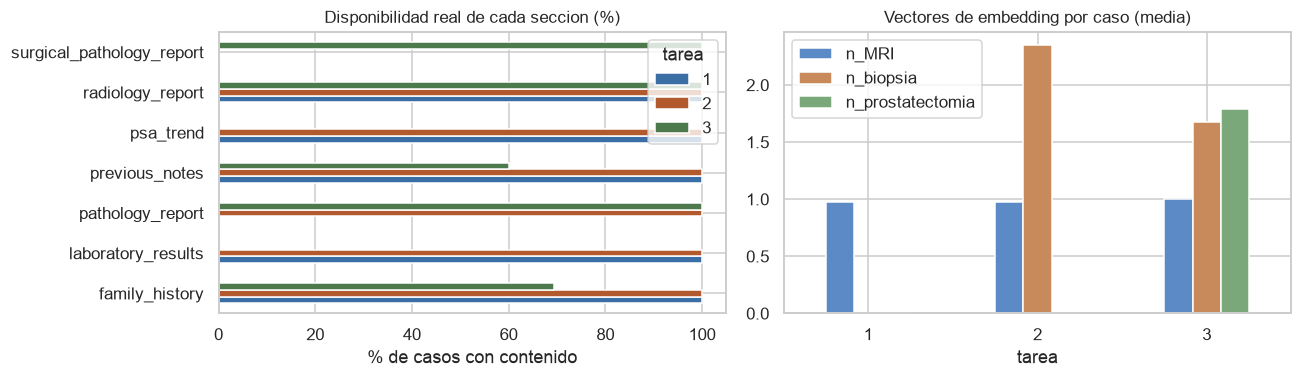

Ejemplos concretos de incompletitud (los que hay que sobrevivir en inferencia):
  · T1 con PI-RADS no numerico: [(1, 'PT-pseudo_3646e0a2ae13', 'pirads')]  (total 1)
  · T3 sin previous_notes: 30/75   sin family_history: 23/75
  · T3 con active_treatment_prior_to_surgery informado: 2/75
  · T1 sin vector de MRI: 4 -> ['PT-pseudo_4bfd4ec864d8', 'PT-pseudo_4d54f04e26ae', 'PT-pseudo_7dbdcd6f9064', 'PT-pseudo_8636aa471ef7']


In [68]:
CENTINELAS = {'not reported', 'unknown', 'none', 'not done', 'n/a', 'na', '—', '-', ''}

def censo_prompt(task):
    fs = [prompt_de(task, c) for c in casos(task)]
    n = len(fs)
    reg = []
    claves = sorted({k for f in fs for k in f})
    for k in claves:
        presentes = sum(1 for f in fs if k in f)
        vacios = sum(1 for f in fs if f.get(k) in (None, '', [], {}))
        cent = sum(1 for f in fs if isinstance(f.get(k), str) and f[k].strip().lower() in CENTINELAS)
        reg.append({'campo': k, 'presente %': 100 * presentes / n, 'vacio %': 100 * vacios / n,
                    'centinela %': 100 * cent / n, 'utilizable %': 100 * (n - vacios - cent) / n})
    return pd.DataFrame(reg).sort_values('utilizable %')

for t in (1, 2, 3):
    d = censo_prompt(t)
    flojos = d[d['utilizable %'] < 100]
    caja(f'{NOMBRE_TAREA[t]} · campos del structured-prompt que NO llegan completos ({len(flojos)} de {len(d)})')
    display(flojos.round(1).style.hide(axis='index').background_gradient('Reds_r', subset=['utilizable %']))

# Secciones detras de herramientas
filas = []
for t in (1, 2, 3):
    cs = [clinico_de(t, c) or {} for c in casos(t)]
    n = len(cs)
    for k in sorted({k for c in cs for k in c if k != 'case_id'}):
        con = sum(1 for c in cs if c.get(k) not in (None, '', [], {}))
        filas.append({'tarea': t, 'seccion': k, 'con contenido %': 100 * con / n, 'null/vacio': n - con, 'casos': n})
clin = pd.DataFrame(filas)
caja('Secciones del clinical-data: la herramienta existe, pero puede devolver "No data available"')
display(clin.pivot_table(index='seccion', columns='tarea', values='con contenido %').round(1).fillna(0)
        .style.background_gradient('RdYlGn', vmin=0, vmax=100).format('{:.0f}%'))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
p = clin.pivot_table(index='seccion', columns='tarea', values='con contenido %').fillna(0)
p.plot.barh(ax=ax[0], color=[PAL[1], PAL[2], PAL[3]])
ax[0].set_title('Disponibilidad real de cada seccion (%)'); ax[0].set_xlabel('% de casos con contenido'); ax[0].set_ylabel('')
orig = INV.groupby('tarea')[['n_MRI', 'n_biopsia', 'n_prostatectomia']].mean()
orig.plot.bar(ax=ax[1], color=['#5b8ac7', '#c98a5b', '#7aa87a'])
ax[1].set_title('Vectores de embedding por caso (media)'); ax[1].set_xlabel('tarea'); ax[1].tick_params(axis='x', rotation=0)
plt.show()

print('Ejemplos concretos de incompletitud (los que hay que sobrevivir en inferencia):')
malos = [(1, c, 'pirads') for c in casos(1) if str(prompt_de(1, c).get('pirads')).upper() in {'NA', 'NONE', ''}]
print(f'  · T1 con PI-RADS no numerico: {malos[:3]}  (total {len(malos)})')
sin_notas = [c for c in casos(3) if (clinico_de(3, c) or {}).get('previous_notes') in (None, '', [])]
sin_fh    = [c for c in casos(3) if (clinico_de(3, c) or {}).get('family_history') in (None, '', [])]
print(f'  · T3 sin previous_notes: {len(sin_notas)}/75   sin family_history: {len(sin_fh)}/75')
print(f'  · T3 con active_treatment_prior_to_surgery informado: '
      f'{sum(1 for c in casos(3) if prompt_de(3, c).get("active_treatment_prior_to_surgery") not in (None, ""))}/75')
sin_emb = INV[(INV.tarea == 1) & (INV.n_MRI == 0)]['case_id'].tolist()
print(f'  · T1 sin vector de MRI: {len(sin_emb)} -> {sin_emb[:5]}')

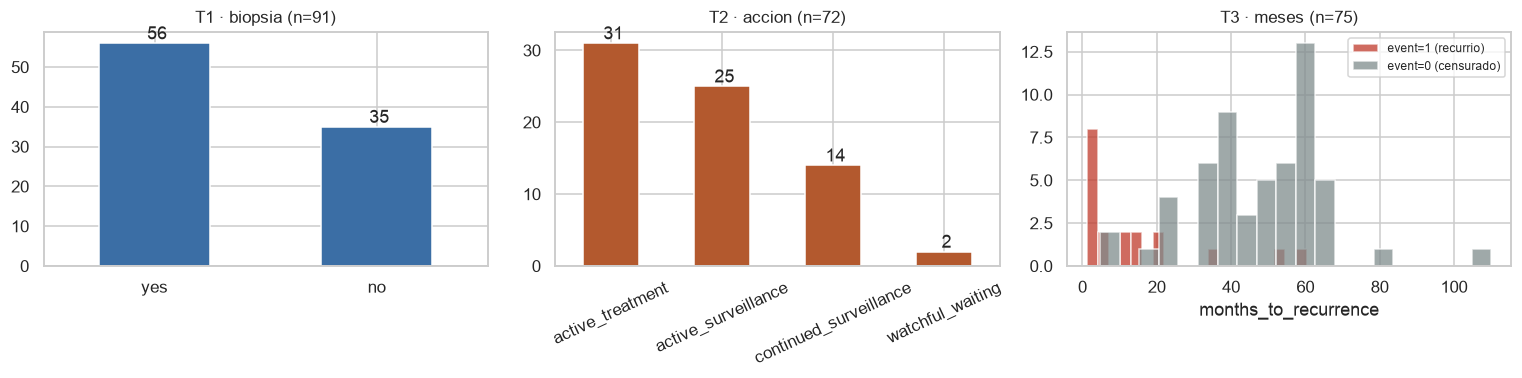

T1: {'yes': 0.615, 'no': 0.385}
T2: {'active_treatment': 0.431, 'active_surveillance': 0.347, 'continued_surveillance': 0.194, 'watchful_waiting': 0.028}  <- watchful_waiting: 2 casos de 72
T3: event=1 19 · event=0 (censurados) 56 = 74.7%
    mediana de meses  event=1: 6.2 · event=0: 48.7


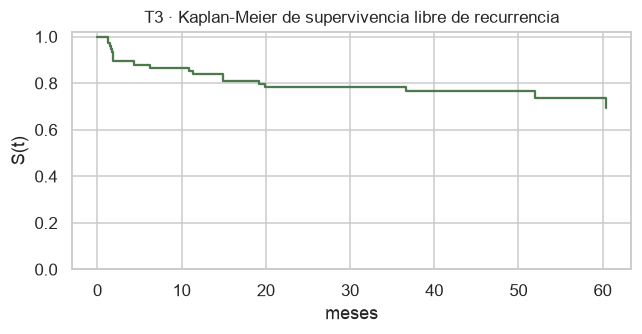


T1 · forma del razonamiento del urologo (n=91)
confidence: {'clear': 58, 'borderline': 18, 'uncertain': 15}
longitud de reveal_sequence: {0: 2, 1: 7, 2: 8, 3: 34, 4: 40}
longitud del free_text (mediana): 73 caracteres


,not_used,noted,important,decisive
psad,9,52,25,5
vol,4,69,16,2
pirads,1,0,45,45
dre,2,64,24,1
fh,24,64,3,0
comorbidity,21,63,7,0
cspca,59,19,11,0
age,1,31,56,3
bx,3,24,46,18
psa,1,29,51,10



T2 · forma del razonamiento del urologo (n=72)
confidence: {'clear': 58, 'borderline': 14}
longitud de reveal_sequence: {0: 72}
longitud del free_text (mediana): 71 caracteres


,not_used,noted,important,decisive
bx_gl_prim,10,23,13,6
pirads,4,21,37,10
bx_isup,0,2,28,22
ct,10,32,29,1
fh,17,51,3,1
comorbidity,6,44,18,4
psa,1,19,43,9
bx_gl_sec,8,25,11,8
age,4,14,45,9
psad,19,40,13,0



ARTEFACTO IMPORTANTE: en T2 las 72 reveal_sequence del ground truth local vienen VACIAS,
mientras que el ground truth del evaluador oficial trae 5-6 revelaciones. Cualquier tool_score
que midamos en T2 con estos datos sale 0 por construccion — no es culpa del agente.


In [69]:
# --- 2.5 Que dicen las etiquetas: distribuciones y forma del ground truth --
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

y1 = pd.Series([gt_de(1, c)['decision'] for c in casos(1, 'ground_truth')])
y1.value_counts().plot.bar(ax=axes[0], color=PAL[1]); axes[0].set_title(f'T1 · biopsia (n={len(y1)})')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(y1.value_counts()): axes[0].text(i, v, f' {v}', ha='center', va='bottom')

y2 = pd.Series([gt_de(2, c)['decision'] for c in casos(2, 'ground_truth')])
y2.value_counts().plot.bar(ax=axes[1], color=PAL[2]); axes[1].set_title(f'T2 · accion (n={len(y2)})')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(y2.value_counts()): axes[1].text(i, v, f' {v}', ha='center', va='bottom')

g3 = [gt_de(3, c)['decision'] for c in casos(3, 'ground_truth')]
t3 = pd.DataFrame(g3)
for ev_, col, lab in [(1, '#c0392b', 'event=1 (recurrio)'), (0, '#7f8c8d', 'event=0 (censurado)')]:
    axes[2].hist(t3[t3.event == ev_]['months_to_recurrence'], bins=20, alpha=.75, color=col, label=lab)
axes[2].set_title(f'T3 · meses (n={len(t3)})'); axes[2].set_xlabel('months_to_recurrence'); axes[2].legend(fontsize=8)
plt.show()

print('T1:', y1.value_counts(normalize=True).round(3).to_dict())
print('T2:', y2.value_counts(normalize=True).round(3).to_dict(), ' <- watchful_waiting: 2 casos de 72')
print('T3: event=1', int((t3.event == 1).sum()), '· event=0 (censurados)', int((t3.event == 0).sum()),
      f'= {100 * (t3.event == 0).mean():.1f}%')
print('    mediana de meses  event=1:', round(t3[t3.event == 1]['months_to_recurrence'].median(), 1),
      '· event=0:', round(t3[t3.event == 0]['months_to_recurrence'].median(), 1))

# Kaplan-Meier de la cohorte (implementado a mano, sin dependencias nuevas)
def km(tiempos, eventos):
    orden = np.argsort(tiempos); t_, e_ = np.array(tiempos)[orden], np.array(eventos)[orden]
    n, s, xs, ys = len(t_), 1.0, [0.0], [1.0]
    for i, (ti, ei) in enumerate(zip(t_, e_)):
        en_riesgo = n - i
        if ei == 1:
            s *= (1 - 1 / en_riesgo); xs.append(ti); ys.append(s)
    return xs, ys

xs, ys = km(t3['months_to_recurrence'].tolist(), t3['event'].tolist())
plt.figure(figsize=(6, 3.2)); plt.step(xs, ys, where='post', color=PAL[3])
plt.title('T3 · Kaplan-Meier de supervivencia libre de recurrencia'); plt.xlabel('meses'); plt.ylabel('S(t)')
plt.ylim(0, 1.02); plt.show()

# La forma del razonamiento en el ground truth (T1/T2)
for t in (1, 2):
    rz = [gt_de(t, c)['razonamiento'] for c in casos(t, 'ground_truth')]
    conf = pd.Series([r.get('confidence') for r in rz]).value_counts()
    largos = pd.Series([len(r.get('reveal_sequence') or []) for r in rz]).value_counts().sort_index()
    pesos = pd.DataFrame([r.get('variable_weights', {}) for r in rz])
    caja(f'T{t} · forma del razonamiento del urologo (n={len(rz)})')
    print('confidence:', conf.to_dict())
    print('longitud de reveal_sequence:', largos.to_dict())
    print('longitud del free_text (mediana):', int(np.median([len(r.get('free_text') or '') for r in rz])), 'caracteres')
    display((pesos.apply(pd.Series.value_counts).T.fillna(0).astype(int)
             [['not_used', 'noted', 'important', 'decisive']]))
print('\nARTEFACTO IMPORTANTE: en T2 las 72 reveal_sequence del ground truth local vienen VACIAS,')
print('mientras que el ground truth del evaluador oficial trae 5-6 revelaciones. Cualquier tool_score')
print('que midamos en T2 con estos datos sale 0 por construccion — no es culpa del agente.')

## Anlisis de un ejemplo

Aqui analizaremos un ejemplo por cada tarea y como el basilen se comporta para cada uno, que entrega y como lo entrega y cual es el reusltado del ejemplo total y como este se comporta.

---

Un caso por tarea, en seis pasos y en el mismo orden en que ocurre de verdad:

1. **3.1** el prompt literal que entra al LLM,
2. **3.2** el catalogo de herramientas tal como el LLM las ve, y **lo que devuelve cada una** para ese caso (servidor MCP real),
3. **3.3** la salida del baseline frente al ground truth,
4. **3.4** la **puntuacion descompuesta** de ese caso con el evaluador oficial (por que saco lo que saco),
5. **3.5** la **traza del grafo** — replay determinista, sin GPU, con todos los mensajes y el prompt del `form_fill`,
6. **3.6** opcional: el agente **de verdad**, con el LLM cargado, instrumentado para volcar cada llamada.

In [70]:
# Un caso por tarea: etiquetado, con prediccion, y no trivial.
def elegir_caso(task, preferencia=None):
    aptos = [c for c in casos(task) if gt_de(task, c) and pred_de(task, c)]
    if preferencia and preferencia in aptos: return preferencia
    return aptos[0]

CASOS_FOCO = {1: elegir_caso(1), 2: elegir_caso(2, 'T2-001'), 3: elegir_caso(3, 'T3-001')}
print('Casos foco:', CASOS_FOCO)

for t, cid in CASOS_FOCO.items():
    caja(f'3.1  {NOMBRE_TAREA[t]} · {cid} — PROMPT LITERAL (lo unico que el LLM ve sin llamar a nada)')
    txt = render_prompt(t, cid)
    print(txt)
    print(f'\n[{len(txt)} caracteres · ~{len(txt) // 4} tokens aprox]')

Casos foco: {1: 'PT-pseudo_0020cfca66c8', 2: 'T2-001', 3: 'T3-001'}

3.1  T1 · decision de biopsia · PT-pseudo_0020cfca66c8 — PROMPT LITERAL (lo unico que el LLM ve sin llamar a nada)
You are a senior urologist reviewing a patient case. The structured clinical
record below is shown to you up front, exactly as in the reading form. Some
documents are not shown and must be pulled up via the available tools
(radiology / MRI report, pathology report, previous notes, laboratory
results, PSA history, and the family-history anamnesis) when you need to
consult them.

Case ID: PT-pseudo_0020cfca66c8
Task: 1

Encounter: Urology - outpatient on 13 Jan 2025.
Referrer: Dr. C. Peters (GP).
Type: Re-evaluation - prior PCa diagnosis.

Clinical data (read-only — values loaded from the record):
  - 67-year-old male
  - PSA: 4.7 ng/mL
  - mpMRI — PI-RADS score: 2 (1–2 low · 3 equivocal · 4–5 high risk)
  - PSA density: 0.14 ng/mL²
  - PSA velocity: 0.48 ng/mL/yr
  - Prior PSA: 4.4 ng/mL
  - Prostate volum

In [71]:
# --- 3.2 El catalogo MCP real y lo que devuelve cada herramienta -----------
import sys as _sys
from langchain_mcp_adapters.client import MultiServerMCPClient

def cliente_mcp(task, con_predictor=False):
    args = ['-m', 'chimera_agent_baseline.mcp_server',
            '--data-dir', str(DATA / f'task{task}' / 'agent_input'),
            '--resource-dir', 'resources', '--tool-registry', f'task{task}', '--log-level', 'ERROR']
    if con_predictor: args.append('--enable-predictor')
    return MultiServerMCPClient({'chimera': {'command': _sys.executable, 'args': args, 'transport': 'stdio'}})

def texto_tool(resultado):
    # el adaptador devuelve bloques de contenido; nos quedamos con el texto
    if isinstance(resultado, str): return resultado
    if isinstance(resultado, list):
        return '\n'.join(b.get('text', '') for b in resultado if isinstance(b, dict))
    return str(resultado)

HERRAMIENTAS = {}
if EJECUTAR_MCP_EN_VIVO:
    for t, cid in CASOS_FOCO.items():
        tools = await cliente_mcp(t).get_tools()
        HERRAMIENTAS[t] = tools
        caja(f'3.2  {NOMBRE_TAREA[t]} · {cid} — {len(tools)} herramientas expuestas por el servidor MCP')
        display(pd.DataFrame([{'tool': x.name, 'argumentos': json.dumps(x.args),
                               'descripcion (lo que lee el LLM)': (x.description or '').replace('\n', ' ')[:150]}
                              for x in tools]).style.hide(axis='index'))
        for x in tools:
            if x.name == 'search_guidelines': continue      # se prueba en la seccion 5
            r = texto_tool(await x.ainvoke({'case_id': cid}))
            try:  r = json.dumps(json.loads(r), indent=2, ensure_ascii=False)
            except Exception: pass
            print(f'\n--- {x.name}({cid}) ---')
            print(envolver(r[:1200], 104, '    '))
            if len(r) > 1200: print(f'    ... [{len(r)} caracteres]')
else:
    print('EJECUTAR_MCP_EN_VIVO = False — no se arranca el servidor MCP.')


3.2  T1 · decision de biopsia · PT-pseudo_0020cfca66c8 — 6 herramientas expuestas por el servidor MCP


tool,argumentos,descripcion (lo que lee el LLM)
get_psa_trend,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}",Retrieve the patient's prior PSA measurements as a time series (date + value). Reveals PSA velocity / trajectory beyond the single headline value alre
get_lab_results,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the full laboratory panel for the patient (PSA, free PSA, haematology, renal function, testosterone, alkaline phosphatase, LDH, etc.) as a li"
get_mri_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the radiologist's full mpMRI report as free text. The headline imaging values (PI-RADS, prostate volume, PSA density, AI csPCa probability) a"
get_previous_notes,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve previous GP / urology consultation notes for this patient, as a list of {date, author, text}."
get_family_history,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Ask the patient about their first-degree family history of prostate cancer (father / brothers). Returns 'Yes', 'No', or 'Unknown'. This is anamnesis e"
search_guidelines,"{""query"": {""title"": ""Query"", ""type"": ""string""}}",Search clinical guidelines and protocols relevant to the query. Uses semantic similarity search over a knowledge base of clinical gui



--- get_psa_trend(PT-pseudo_0020cfca66c8) ---
    {
      "case_id": "PT-pseudo_0020cfca66c8",
      "psa_trend": [
        {
          "date": "Feb 2022",
          "val": 4.2
        },
        {
          "date": "Feb 2023",
          "val": 2.8
        },
        {
          "date": "Jan 2024",
          "val": 0.6
        },
        {
          "date": "Jan 2025",
          "val": 4.7
        }
      ]
    }

--- get_lab_results(PT-pseudo_0020cfca66c8) ---
    {
      "case_id": "PT-pseudo_0020cfca66c8",
      "laboratory_results": [
        {
          "name": "PSA",
          "val": "4.7 ng/mL",
          "date": "22 Dec 2024",
          "flag": "H"
        },
        {
          "name": "Free PSA",
          "val": "1.21 ng/mL",
          "date": "22 Dec 2024",
          "flag": ""
        },
        {
          "name": "%Free PSA",
          "val": "26%",
          "date": "22 Dec 2024",
          "flag": ""
        },
        {
          "name": "Haemoglobin",
          "val

tool,argumentos,descripcion (lo que lee el LLM)
get_psa_trend,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}",Retrieve the patient's prior PSA measurements as a time series (date + value). Reveals PSA velocity / trajectory beyond the single headline value alre
get_lab_results,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the full laboratory panel for the patient (PSA, free PSA, haematology, renal function, testosterone, alkaline phosphatase, LDH, etc.) as a li"
get_mri_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the radiologist's full mpMRI report as free text. The headline imaging values (PI-RADS, prostate volume, PSA density, AI csPCa probability) a"
get_pathology_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the pathologist's full biopsy report as free text. The headline biopsy values (Gleason patterns, ISUP grade group) are already in the prompt"
get_previous_notes,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve previous GP / urology consultation notes for this patient, as a list of {date, author, text}."
get_family_history,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Ask the patient about their first-degree family history of prostate cancer (father / brothers). Returns 'Yes', 'No', or 'Unknown'. This is anamnesis e"
search_guidelines,"{""query"": {""title"": ""Query"", ""type"": ""string""}}",Search clinical guidelines and protocols relevant to the query. Uses semantic similarity search over a knowledge base of clinical gui



--- get_psa_trend(T2-001) ---
    {
      "case_id": "T2-001",
      "psa_trend": [
        {
          "date": "Jan 2024",
          "val": 1.6
        },
        {
          "date": "Apr 2024",
          "val": 2.1
        },
        {
          "date": "Jul 2024",
          "val": 2.7
        },
        {
          "date": "Oct 2024",
          "val": 3.6
        },
        {
          "date": "Jan 2025",
          "val": 4.7
        }
      ]
    }

--- get_lab_results(T2-001) ---
    {
      "case_id": "T2-001",
      "laboratory_results": [
        {
          "name": "PSA",
          "val": "4.7 ng/mL",
          "date": "03 Jan 2025",
          "flag": "H"
        },
        {
          "name": "Free PSA",
          "val": "0.67 ng/mL",
          "date": "03 Jan 2025",
          "flag": ""
        },
        {
          "name": "%Free PSA",
          "val": "14%",
          "date": "03 Jan 2025",
          "flag": "L"
        },
        {
          "name": "Haemoglobin",
     

tool,argumentos,descripcion (lo que lee el LLM)
get_mri_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the radiologist's full mpMRI report as free text. The headline imaging values (PI-RADS, prostate volume, PSA density, AI csPCa probability) a"
get_pathology_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the pathologist's full biopsy report as free text. The headline biopsy values (Gleason patterns, ISUP grade group) are already in the prompt"
get_surgical_pathology_report,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve the surgical (radical prostatectomy) pathology report as free text: post-operative ISUP grade, margins, extraprostatic extension, seminal-ves"
get_previous_notes,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Retrieve previous GP / urology consultation notes for this patient, as a list of {date, author, text}."
get_family_history,"{""case_id"": {""title"": ""Case Id"", ""type"": ""string""}}","Ask the patient about their first-degree family history of prostate cancer (father / brothers). Returns 'Yes', 'No', or 'Unknown'. This is anamnesis e"
search_guidelines,"{""query"": {""title"": ""Query"", ""type"": ""string""}}",Search clinical guidelines and protocols relevant to the query. Uses semantic similarity search over a knowledge base of clinical gui



--- get_mri_report(T3-001) ---
    {
      "case_id": "T3-001",
      "radiology_report": "Prostate volume: 37.29 cc. PSA density: 2.306 ng/mL/cc. PI-RADS: 5. AI model-
    predicted probability of clinically significant prostate cancer (0–1): 0.9527162."
    }

--- get_pathology_report(T3-001) ---
    {
      "case_id": "T3-001",
      "pathology_report": "The patient underwent one biopsy session. At biopsy, Gleason 4+4 (ISUP grade
    group 4, AI model-predicted ISUP 5) was identified in the left base; cribriform pattern was present.
    The reported histological growth pattern was: Adenocarcinoma."
    }

--- get_surgical_pathology_report(T3-001) ---
    {
      "case_id": "T3-001",
      "surgical_pathology_report": "The robot-assisted radical prostatectomy specimen showed Gleason 4+3
    (ISUP grade group 3), pathological stage pT4b. Extraprostatic extension was present; surgical
    margins were positive; the seminal vesicles were invaded; lymphovascular invasion was absent; lym

In [72]:
# --- 3.3 Salida del baseline vs ground truth, lado a lado -----------------
for t, cid in CASOS_FOCO.items():
    g, p = gt_de(t, cid), pred_de(t, cid)
    caja(f'3.3  {NOMBRE_TAREA[t]} · {cid}')
    print(f'DECISION   ground truth: {json.dumps(g["decision"])}     baseline: {json.dumps(p["decision"])}'
          f'     {"OK" if g["decision"] == p["decision"] else "FALLO"}')
    if t in (1, 2):
        gr, pr = g['razonamiento'], p['razonamiento']
        comp = pd.DataFrame({'ground truth': gr.get('variable_weights', {}),
                             'baseline': pr.get('variable_weights', {})}).fillna('—')
        comp['coincide'] = comp['ground truth'] == comp['baseline']
        display(comp)
        print(f'confidence      GT: {gr.get("confidence"):12} baseline: {pr.get("confidence")}')
        print(f'reveal_sequence GT: {gr.get("reveal_sequence")}')
        print(f'reveal_sequence BL: {pr.get("reveal_sequence")}')
        print('\nfree_text GT:'); print(envolver(gr.get('free_text'), 104, '    '))
        print('free_text BL:');  print(envolver(pr.get('free_text'), 104, '    '))
    else:
        print(f'meses           GT: {g["decision"].get("months_to_recurrence")}    baseline: {p["decision"].get("months_to_recurrence")}')
        print(f'event           GT: {g["decision"].get("event")}                   baseline: {p["decision"].get("event")}')
        print('\nrazonamiento BL:'); print(envolver(p['razonamiento'], 104, '    '))


3.3  T1 · decision de biopsia · PT-pseudo_0020cfca66c8
DECISION   ground truth: "no"     baseline: "yes"     FALLO


,ground truth,baseline,coincide
psad,noted,not_used,False
vol,noted,not_used,False
pirads,decisive,noted,False
dre,noted,not_used,False
fh,noted,important,False
comorbidity,noted,not_used,False
cspca,not_used,noted,False
age,noted,not_used,False
bx,not_used,not_used,True
psa,important,important,True


confidence      GT: clear        baseline: borderline
reveal_sequence GT: ['radiology_report', 'psa_trend', 'laboratory_results', 'previous_notes']
reveal_sequence BL: ['radiology_report', 'laboratory_results', 'psa_trend', 'previous_notes', 'family_history']

free_text GT:
    Priads 2 with only sightly elevated PSA
free_text BL:
    Decision driven by the conflict between a low-risk PI-RADS 2 score and the rising PSA trend. Key
    factors were: 1) Rising PSA over time, 2) Presence of a prior positive biopsy, and 3) Positive
    family history, which collectively increased the pre-test probability.

3.3  T2 · decision de tratamiento · T2-001
DECISION   ground truth: "active_surveillance"     baseline: "active_surveillance"     OK


,ground truth,baseline,coincide
bx_gl_prim,important,important,True
pirads,decisive,decisive,True
bx_isup,decisive,important,False
ct,important,noted,False
fh,noted,important,False
comorbidity,noted,not_used,False
psa,important,important,True
bx_gl_sec,important,not_used,False
age,not_used,not_used,True
psad,important,not_used,False


confidence      GT: clear        baseline: clear
reveal_sequence GT: []
reveal_sequence BL: ['radiology_report', 'pathology_report', 'psa_trend', 'family_history']

free_text GT:
    Patient with GG 1 on active surveillance, negative follow-up imaging.
free_text BL:
    The decision to recommend Active Surveillance is driven by the combination of low-risk imaging (PI-
    RADS 2), low-grade pathology (Gleason 3+3), and the necessity to monitor the concerningly rising PSA
    trend.

3.3  T3 · tiempo a recurrencia bioquimica · T3-001
DECISION   ground truth: {"months_to_recurrence": 1.8, "event": 1}     baseline: {"event": 0, "months_to_recurrence": 9.0}     FALLO
meses           GT: 1.8    baseline: 9.0
event           GT: 1                   baseline: 0

razonamiento BL:
    The high-risk profile driven by Gleason 4+4, presence of lymph node metastasis in the surgical
    report, and pathological stage pT4b significantly elevates the risk for biochemical recurrence
    within the firs

In [73]:
# --- 3.4 Puntuacion del caso, descompuesta con el evaluador oficial -------
from score_local import load_predictions      # dev/score_local.py: adapta test/output/ al shape del evaluador

PRED_PLANAS = {t: load_predictions(SALIDA, t) for t in (1, 2, 3)}
GT_REGISTROS = {t: {EV.get_case_id(g): g for g in
                    EV.load_ground_truth_records(DATA / f'task{t}' / 'ground_truth', f'task{t}')}
                for t in (1, 2, 3)}

PESOS_SIN_JUEZ = {'confidence_score': 0.225, 'variable_weight_score': 0.275,
                  'important_decisive_factor_score': 0.175, 'section_grounding_score': 0.175,
                  'tool_score': 0.150}
PESOS_T3_SIN_JUEZ = {'event_score': 0.50, 'time_score': 0.50}

def puntuar_caso(task, cid):
    return EV.evaluate_case(GT_REGISTROS[task][cid], PRED_PLANAS[task].get(cid), None, None)

def descomponer(task, cid):
    fila = puntuar_caso(task, cid)
    caja(f'3.4  {NOMBRE_TAREA[task]} · {cid} — case_score = {fila["case_score"]:.4f}   (puerta: {fila["gate"]})')
    pesos = PESOS_T3_SIN_JUEZ if task == 3 else PESOS_SIN_JUEZ
    tabla = []
    for k, w in pesos.items():
        v = fila.get(k)
        tabla.append({'componente': k, 'valor': v, 'peso': w,
                      'aporta': (v or 0.0) * w, 'perdido': (1 - (v or 0.0)) * w})
    df = pd.DataFrame(tabla)
    df.loc[len(df)] = {'componente': 'TOTAL', 'valor': None, 'peso': sum(pesos.values()),
                       'aporta': df['aporta'].sum(), 'perdido': df['perdido'].sum()}
    display(df.style.hide(axis='index').format({'valor': '{:.3f}', 'peso': '{:.3f}',
                                                'aporta': '{:.4f}', 'perdido': '{:.4f}'}, na_rep='—'))
    print('razon del evaluador:', fila.get('reason'))
    return fila

FILAS_FOCO = {t: descomponer(t, cid) for t, cid in CASOS_FOCO.items()}
print('\nEn T1/T2 la decision es una PUERTA: si falla, todo lo de arriba no se calcula y el caso vale 0.')


3.4  T1 · decision de biopsia · PT-pseudo_0020cfca66c8 — case_score = 0.0000   (puerta: biopsy_decision_failed)


componente,valor,peso,aporta,perdido
confidence_score,—,0.225,0.0000,0.2250
variable_weight_score,—,0.275,0.0000,0.2750
important_decisive_factor_score,—,0.175,0.0000,0.1750
section_grounding_score,—,0.175,0.0000,0.1750
tool_score,—,0.150,0.0000,0.1500
TOTAL,—,1.000,0.0000,1.0000


razon del evaluador: biopsy_decision mismatch: gt='no' pred='yes'

3.4  T2 · decision de tratamiento · T2-001 — case_score = 0.6994   (puerta: passed)


componente,valor,peso,aporta,perdido
confidence_score,1.000,0.225,0.2250,0.0000
variable_weight_score,0.697,0.275,0.1917,0.0833
important_decisive_factor_score,0.615,0.175,0.1077,0.0673
section_grounding_score,1.000,0.175,0.1750,0.0000
tool_score,0.000,0.150,0.0000,0.1500
TOTAL,—,1.000,0.6994,0.3006


razon del evaluador: tool: precision=0.000 extra=4/4 extra_keys=['family_history', 'pathology_report', 'psa_trend', 'radiology_report']

3.4  T3 · tiempo a recurrencia bioquimica · T3-001 — case_score = 0.0000   (puerta: passed)


componente,valor,peso,aporta,perdido
event_score,0.000,0.500,0.0000,0.5000
time_score,0.000,0.500,0.0000,0.5000
TOTAL,—,1.000,0.0000,1.0000


razon del evaluador: event=0.0 time=0.000

En T1/T2 la decision es una PUERTA: si falla, todo lo de arriba no se calcula y el caso vale 0.


### 3.5 Trazabilidad del razonamiento: replay determinista del grafo

El baseline **no persiste ninguna traza**: `run.py` guarda solo los dos JSON de salida y descarta el historial de
mensajes, los resultados de las herramientas y los avisos del `form_fill`. Asi que para *ver* como razona hay dos
caminos, y aqui estan los dos:

- **replay determinista** (esta celda): montamos el **mismo grafo real** — mismas herramientas MCP, mismo nodo
  `form_fill`, mismo prompt de sistema — pero con un LLM *guionizado* que emite respuestas fijas. Sirve para leer la
  mecanica exacta: cuando se enrutan las herramientas, que texto recibe el `form_fill`, como se deriva
  `reveal_sequence` de los `ToolMessage`, y como se rellena la forma completa con `not_used`.
- **ejecucion real** (celda 3.6, con `EJECUTAR_AGENTE_EN_VIVO = True`): el LLM de verdad, con la GPU, instrumentado.

In [74]:
# --- El grafo real con un LLM guionizado ----------------------------------
from typing import Any, List, Optional
from langchain_core.language_models import BaseChatModel
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from chimera_agent_baseline.agent.graph import create_graph, AgentState, _route_after_agent
from chimera_agent_baseline.agent.prompts import build_system_prompt
from chimera_agent_baseline.agent import form_fill as FF

class LLMGuionizado(BaseChatModel):
    guion: List[AIMessage] = []
    registro: list = []
    @property
    def _llm_type(self): return 'guionizado'
    def bind_tools(self, tools, **kw): return self          # el grafo llama bind_tools; aqui es un no-op
    def _generate(self, messages, stop=None, run_manager=None, **kw) -> ChatResult:
        self.registro.append(list(messages))
        msg = self.guion[min(len(self.registro) - 1, len(self.guion) - 1)]
        return ChatResult(generations=[ChatGeneration(message=msg)])

print('Estructura del grafo (nodos y aristas reales de agent/graph.py):')
CASO_T2 = CASOS_FOCO[2]
guion = [
    AIMessage(content='Antes de decidir necesito el informe de MRI completo.',
              tool_calls=[{'name': 'get_mri_report', 'args': {'case_id': CASO_T2}, 'id': 'x1'}]),
    AIMessage(content='Y la patologia de la biopsia para el grado ISUP.',
              tool_calls=[{'name': 'get_pathology_report', 'args': {'case_id': CASO_T2}, 'id': 'x2'}]),
    AIMessage(content=('Sintesis: PI-RADS bajo, ISUP 1 estable y PSA moderado. '
                       'Recomiendo vigilancia activa; no hay criterio de tratamiento activo.')),
    AIMessage(content=json.dumps({'case_id': CASO_T2, 'task': 2, 'action': 'active_surveillance',
                                  'confidence': 'clear',
                                  'variable_weights': {k: 'noted' for k in
                                      ['ct', 'age', 'psa', 'psad', 'cspca', 'pirads',
                                       'bx_isup', 'bx_gl_sec', 'bx_gl_prim', 'comorbidity']},
                                  'reasoning': ('ISUP 1 con PI-RADS bajo y PSA moderado: sin criterios de '
                                                'tratamiento activo, procede vigilancia activa con control de PSA.')})),
]

if EJECUTAR_MCP_EN_VIVO:
    tools_t2 = HERRAMIENTAS.get(2) or await cliente_mcp(2).get_tools()
    llm_g = LLMGuionizado(guion=guion)
    grafo = create_graph(tools_t2, llm_g, build_system_prompt(),
                         step_timeout=120, form_fill_max_retries=3)
    print(grafo.get_graph().draw_ascii())
    print('\nAristas:', [(a.source, a.target, a.conditional) for a in grafo.get_graph().edges])
    print('Campos del estado (AgentState):', list(AgentState.__annotations__))
    print('\nRouter tras el nodo agent:'); print(inspect.getsource(_route_after_agent))

    resultado = await grafo.ainvoke(
        {'messages': [HumanMessage(content=render_prompt(2, CASO_T2))], 'case_id': CASO_T2, 'task': 2},
        {'recursion_limit': 25})

    caja(f'TRAZA COMPLETA · {CASO_T2} (LLM guionizado, herramientas y form_fill REALES)')
    for i, m in enumerate(resultado['messages']):
        tipo = type(m).__name__
        etiqueta = {'HumanMessage': 'PROMPT DEL CASO', 'AIMessage': 'LLM', 'ToolMessage': 'RESULTADO DE TOOL',
                    'SystemMessage': 'PROMPT DE SISTEMA'}.get(tipo, tipo)
        print(f'\n[{i}] {etiqueta}' + (f'  ({m.name})' if getattr(m, 'name', None) else ''))
        print(envolver(str(m.content)[:700], 104, '     '))
        if getattr(m, 'tool_calls', None):
            print('     -> tool_calls:', [(c['name'], c['args']) for c in m.tool_calls])
    print('\nDerivados por el nodo form_fill:')
    print('  tools llamadas       :', sorted(FF._called_tools_from_messages(resultado['messages'])))
    print('  reveal_sequence      :', FF._reveal_sequence_from_messages(resultado['messages'], 2))
    from chimera_agent_baseline.output.schema import eligible_variables as _elegibles
    print('  variables elegibles  :', _elegibles(2, FF._called_tools_from_messages(resultado['messages'])))
    print('  avisos de validacion :', resultado.get('form_fill_warnings'))
    print('\nSALIDA ESTRUCTURADA (ya normalizada a la forma completa, con not_used rellenado):')
    ver(resultado['structured_response'], 1600)
else:
    print('EJECUTAR_MCP_EN_VIVO = False — el replay necesita el servidor MCP.')

Estructura del grafo (nodos y aristas reales de agent/graph.py):
        +-----------+            
        | __start__ |            
        +-----------+            
              *                  
              *                  
              *                  
          +-------+              
          | agent |              
          +-------+              
         **        ..            
       **            ..          
      *                .         
+-------+         +-----------+  
| tools |         | form_fill |  
+-------+         +-----------+  
                        *        
                        *        
                        *        
                   +---------+   
                   | __end__ |   
                   +---------+   

Aristas: [('__start__', 'agent', False), ('agent', 'form_fill', True), ('agent', 'tools', True), ('tools', 'agent', False), ('form_fill', '__end__', False)]
Campos del estado (AgentState): ['messages', 'task', 'case_id',


TRAZA COMPLETA · T2-001 (LLM guionizado, herramientas y form_fill REALES)

[0] PROMPT DEL CASO
     You are a senior urologist reviewing a patient case. The structured clinical
     record below is shown to you up front, exactly as in the reading form. Some
     documents are not shown and must be pulled up via the available tools
     (radiology / MRI report, pathology report, previous notes, laboratory
     results, PSA history, and the family-history anamnesis) when you need to
     consult them.
     
     Case ID: T2-001
     Task: 2
     
     Encounter: Urology - outpatient on 27 Jan 2025.
     Referrer: Dr. R. Visser (GP).
     Type: Re-evaluation - prior PCa diagnosis.
     
     Clinical data (read-only — values loaded from the record):
       - 67-year-old male
       - PSA: 4.7 ng/mL
       - mpMRI — PI-RADS score: 2 (1–2 low · 3 equivocal · 4–5 high risk)
       -

[1] LLM
     Antes de decidir necesito el informe de MRI completo.
     -> tool_calls: [('get_mri_report', {

In [75]:
# --- El prompt que el nodo form_fill construye de verdad ------------------
from chimera_agent_baseline.output.schema import build_dynamic_model, eligible_variables

llamadas_demo = {'get_mri_report', 'get_pathology_report'}     # como en el replay de arriba
for t in (1, 2, 3):
    elig = eligible_variables(t, llamadas_demo) if t in VARIABLES_BY_TASK else []
    usuario = FF._user_prompt(CASOS_FOCO[t], t, '<<aqui va el ultimo mensaje del LLM: su sintesis>>',
                              sorted(llamadas_demo), elig)
    esqueleto = FF._build_skeleton_instructions(t, elig)
    caja(f'form_fill · {NOMBRE_TAREA[t]} — prompt de sistema + usuario + esqueleto')
    print('[SYSTEM]'); print(envolver(FF._SYSTEM_PROMPT, 104, '   '))
    print('\n[USER]');  print(envolver(usuario, 104, '   '))
    print('\n[ESQUELETO]'); print(envolver(esqueleto, 104, '   '))
    if t in VARIABLES_BY_TASK:
        Dyn = build_dynamic_model(t, llamadas_demo)
        print(f'\nSchema dinamico generado para esas tools: variables exigidas = '
              f'{list(Dyn.model_fields["variable_weights"].annotation.model_fields)}')
        print('  (fh solo aparece si se llamo a get_family_history — el schema hace cumplir el "no puntues')
        print('   variables detras de una tool que no llamaste" del prompt de sistema)')


form_fill · T1 · decision de biopsia — prompt de sistema + usuario + esqueleto
[SYSTEM]
   You are filling out the structured decision form for the prostate-cancer case you just analysed. The
   user message contains your reasoning transcript and the tools you called. Output a SINGLE JSON object
   matching the supplied schema EXACTLY — no extra keys, no markdown fences, no commentary before or
   after the JSON.

[USER]
   Case ID: PT-pseudo_0020cfca66c8
   Task: 1
   
   Your reasoning transcript (final assistant message from the ReAct loop):
   """
   <<aqui va el ultimo mensaje del LLM: su sintesis>>
   """
   
   Tools you called during the ReAct loop: get_mri_report, get_pathology_report
   
   Variables you may weight (you may ONLY weight these — every other variable was either out of scope
   for this task or behind a tool you did not call):
     bx, age, dre, psa, vol, psad, cspca, pirads, comorbidity
   
   Now fill out the form. Weight each variable (not_used / noted / impo

In [76]:
# --- 3.6 (opcional) El agente de VERDAD, instrumentado --------------------
# Carga el LLM en vLLM (GPU) y corre UN caso capturando cada llamada.
# El volcado queda en delete/traza_<case_id>.json para inspeccion posterior.
from langchain_core.callbacks import BaseCallbackHandler

class Espia(BaseCallbackHandler):
    def __init__(self): self.eventos = []
    def on_chat_model_start(self, serialized, messages, **kw):
        self.eventos.append({'tipo': 'llm_in', 'mensajes': [[type(m).__name__, str(m.content)] for m in messages[0]]})
    def on_llm_end(self, response, **kw):
        g = response.generations[0][0]
        msg = getattr(g, 'message', None)
        self.eventos.append({'tipo': 'llm_out', 'texto': g.text,
                             'tool_calls': getattr(msg, 'tool_calls', None),
                             'extra': {k: v for k, v in (getattr(msg, 'additional_kwargs', {}) or {}).items()
                                       if k in ('reasoning_content',)}})
    def on_tool_start(self, serialized, input_str, **kw):
        self.eventos.append({'tipo': 'tool_in', 'tool': (serialized or {}).get('name'), 'args': input_str})
    def on_tool_end(self, output, **kw):
        self.eventos.append({'tipo': 'tool_out', 'salida': str(output)[:4000]})

if EJECUTAR_AGENTE_EN_VIVO:
    from hydra import compose, initialize_config_dir
    from chimera_agent_baseline.models import load_model
    from chimera_agent_baseline.rag import start_embedding_service

    TAREA_VIVA, CASO_VIVO = 2, CASOS_FOCO[2]
    with initialize_config_dir(config_dir=str(REPO / 'configs'), version_base=None):
        cfg = compose(config_name='config', overrides=['+experiment=local_paths'])
    print('modelo:', cfg.model.model_id, '| provider:', cfg.model.provider, '| temperature:', cfg.generation.temperature)

    svc = start_embedding_service(cfg.paths.embedding_model_dir)
    try:
        modelo = load_model(cfg)                       # <-- carga los pesos en la GPU
        tools_v = await cliente_mcp(TAREA_VIVA).get_tools()
        grafo_v = create_graph(tools_v, modelo, build_system_prompt(),
                               step_timeout=cfg.agent.step_timeout,
                               form_fill_max_retries=cfg.agent.form_fill.max_retries)
        espia = Espia()
        res_v = await grafo_v.ainvoke(
            {'messages': [HumanMessage(content=render_prompt(TAREA_VIVA, CASO_VIVO))],
             'case_id': CASO_VIVO, 'task': TAREA_VIVA},
            {'recursion_limit': cfg.agent.max_iterations, 'callbacks': [espia]})

        caja(f'TRAZA REAL · {CASO_VIVO} · {len(espia.eventos)} eventos capturados')
        for i, e in enumerate(espia.eventos):
            print(f'\n--- [{i}] {e["tipo"]} ---')
            if e['tipo'] == 'llm_in':
                for rol, txt in e['mensajes']: print(f'   {rol}: {envolver(txt[:600], 100, "      ").strip()}')
            elif e['tipo'] == 'llm_out':
                print(envolver(e['texto'][:900], 100, '   '))
                if e['tool_calls']: print('   tool_calls:', e['tool_calls'])
            else:
                print(envolver(json.dumps(e, ensure_ascii=False)[:700], 100, '   '))
        print('\navisos form_fill:', res_v.get('form_fill_warnings'))
        ver(res_v['structured_response'], 1600, 'SALIDA ESTRUCTURADA REAL')
        destino = VOLCADOS / f'traza_{CASO_VIVO}.json'
        destino.write_text(json.dumps({'case_id': CASO_VIVO, 'task': TAREA_VIVA,
                                       'eventos': espia.eventos,
                                       'structured_response': res_v['structured_response'],
                                       'form_fill_warnings': res_v.get('form_fill_warnings')},
                                      indent=2, ensure_ascii=False))
        print('traza guardada en', destino)
    finally:
        if svc: svc.stop()
else:
    print('EJECUTAR_AGENTE_EN_VIVO = False.')
    print('Ponlo en True para cargar el LLM (GPU, ~1-3 min de arranque) y trazar un caso real.')
    print('El replay de 3.5 ya muestra toda la mecanica del grafo sin GPU.')

EJECUTAR_AGENTE_EN_VIVO = False.
Ponlo en True para cargar el LLM (GPU, ~1-3 min de arranque) y trazar un caso real.
El replay de 3.5 ya muestra toda la mecanica del grafo sin GPU.


## 4. Resultados del baseline ya corrido

`test/output/` contiene la corrida del baseline **sin modificar** (Gemma-4-E2B-it en vLLM, `temperature 1.0`,
`max_iterations 25`, predictor apagado). Lo puntuamos con el **evaluador oficial** clonado, con el juez de
razonamiento **desactivado** (modo determinista y reproducible), y contando los casos etiquetados **sin salida
como fallo** — que es lo que hace Grand Challenge cuando un contenedor no entrega.

> Dos formas faciles de medir esto mal: (a) excluir los casos sin salida, que da un numero optimista; y
> (b) comparar un numero con juez contra uno sin juez — al apagar el juez los pesos **se redistribuyen**
> (el grounding sube de 0.05 a 0.175), asi que los dos modos no son comparables entre si.

In [77]:
# --- 4.1 Puntuacion completa, por caso y agregada -------------------------
FILAS, AGREGADOS = {}, {}
for t in (1, 2, 3):
    filas = [EV.evaluate_case(g, PRED_PLANAS[t].get(cid), None, None) for cid, g in GT_REGISTROS[t].items()]
    FILAS[t] = pd.DataFrame(filas)
    AGREGADOS[t] = (EV.aggregate_recurrence_metrics(filas) if t == 3 else EV.compute_aggregate_metrics(filas))

PESO_TAREA = {1: 2.0, 2: 2.0, 3: 1.0}
overall = (sum(AGREGADOS[t]['ranking_score'] * PESO_TAREA[t] for t in (1, 2, 3))
           / sum(PESO_TAREA.values()))

ref = leer_json(REPO / 'dev' / 'baseline_reference.json') or {}
resumen = []
for t in (1, 2, 3):
    a = AGREGADOS[t]
    r = ref.get(f'task{t}', {})
    resumen.append({'tarea': t, 'casos etiquetados': a['n_cases'],
                    'con prediccion': int(FILAS[t]['gate'].ne('missing_candidate').sum()),
                    'perdidos': int(FILAS[t]['gate'].eq('missing_candidate').sum()),
                    'mean_case_score': a['mean_case_score'],
                    'ranking_score': a['ranking_score'],
                    'ranking (referencia)': r.get('ranking_score'),
                    'peso': PESO_TAREA[t]})
res = pd.DataFrame(resumen)
res['delta vs referencia'] = res['ranking_score'] - res['ranking (referencia)']
display(res.style.hide(axis='index').format({'mean_case_score': '{:.4f}', 'ranking_score': '{:.4f}',
                                             'ranking (referencia)': '{:.4f}', 'delta vs referencia': '{:+.4f}'},
                                            na_rep='—'))
print(f'OVERALL RANKING SCORE (media ponderada 2:2:1) = {overall:.4f}')
print(f'referencia guardada en dev/baseline_reference.json = 0.5651')
print('\nSobre los deltas: test/output NO es bit a bit la corrida que produjo la referencia.')
print('  · T1 tiene ahora 1 caso etiquetado sin salida (baja el ranking ~0.008).')
print('  · T3: el c-index depende de los meses predichos, y con temperature=1.0 esos numeros')
print('    cambian entre corridas. Medir siempre de nuevo antes de comparar una mejora.')
print('\nOJO con la metrica de ranking de T3: es SOLO el c-index (ordenacion del riesgo).')
print('  mean_time_score y mean_event_score entran en mean_case_score, que NO es lo que rankea T3.')
print('\nDetalle de las puertas:')
for t in (1, 2, 3):
    print(f'  task{t}: {FILAS[t]["gate"].value_counts().to_dict()}')
print('\nMetricas propias de T3:', {k: (round(v, 4) if isinstance(v, float) else v)
                                    for k, v in AGREGADOS[3].items()
                                    if k in ('recurrence_event_accuracy', 'mean_event_score', 'mean_time_score',
                                             'event1_time_mae_months', 'concordance_index', 'mean_time_dependent_auc')})
print('AUC dependiente del tiempo:', {k: round(v, 3) for k, v in (AGREGADOS[3].get('time_dependent_auc') or {}).items()})

tarea,casos etiquetados,con prediccion,perdidos,mean_case_score,ranking_score,ranking (referencia),peso,delta vs referencia
1,91,90,1,0.4734,0.6268,0.6351,2.000000,-0.0083
2,72,72,0,0.3690,0.4457,0.4457,2.000000,-0.0001
3,75,73,2,0.5419,0.6823,0.6636,1.000000,+0.0187


OVERALL RANKING SCORE (media ponderada 2:2:1) = 0.5654
referencia guardada en dev/baseline_reference.json = 0.5651

Sobre los deltas: test/output NO es bit a bit la corrida que produjo la referencia.
  · T1 tiene ahora 1 caso etiquetado sin salida (baja el ranking ~0.008).
  · T3: el c-index depende de los meses predichos, y con temperature=1.0 esos numeros
    cambian entre corridas. Medir siempre de nuevo antes de comparar una mejora.

OJO con la metrica de ranking de T3: es SOLO el c-index (ordenacion del riesgo).
  mean_time_score y mean_event_score entran en mean_case_score, que NO es lo que rankea T3.

Detalle de las puertas:
  task1: {'passed': 60, 'biopsy_decision_failed': 30, 'missing_candidate': 1}
  task2: {'passed': 41, 'treatment_decision_failed': 31}
  task3: {'passed': 73, 'missing_candidate': 2}

Metricas propias de T3: {'recurrence_event_accuracy': 0.7397, 'mean_event_score': 0.7397, 'mean_time_score': 0.3738, 'event1_time_mae_months': 19.5211, 'concordance_index': 0.6

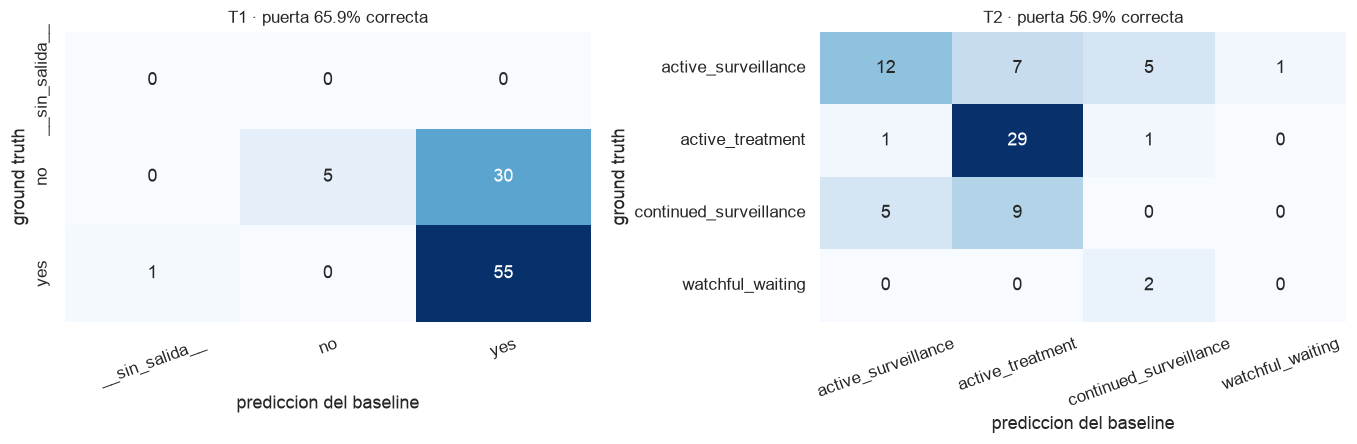


T1 · informe de clasificacion de la decision
                precision    recall  f1-score   support

__sin_salida__       0.00      0.00      0.00         0
            no       1.00      0.14      0.25        35
           yes       0.65      0.98      0.78        56

      accuracy                           0.66        91
     macro avg       0.55      0.38      0.34        91
  weighted avg       0.78      0.66      0.58        91


T2 · informe de clasificacion de la decision
                        precision    recall  f1-score   support

   active_surveillance       0.67      0.48      0.56        25
      active_treatment       0.64      0.94      0.76        31
continued_surveillance       0.00      0.00      0.00        14
      watchful_waiting       0.00      0.00      0.00         2

              accuracy                           0.57        72
             macro avg       0.33      0.35      0.33        72
          weighted avg       0.51      0.57      0.52        72

In [78]:
# --- 4.2 La puerta de decision: matrices de confusion ---------------------
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, t in zip(axes, (1, 2)):
    d = FILAS[t].copy()
    d['pred_decision'] = d['pred_decision'].fillna('__sin_salida__')
    etiquetas = sorted(set(d['gt_decision'].dropna()) | set(d['pred_decision']))
    cm = confusion_matrix(d['gt_decision'], d['pred_decision'], labels=etiquetas)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas,
                cbar=False, ax=ax)
    ax.set_title(f'T{t} · puerta {100 * d["decision_score"].eq(1.0).mean():.1f}% correcta')
    ax.set_xlabel('prediccion del baseline'); ax.set_ylabel('ground truth')
    ax.tick_params(axis='x', rotation=20)
plt.show()

for t in (1, 2):
    d = FILAS[t].copy(); d['pred_decision'] = d['pred_decision'].fillna('__sin_salida__')
    caja(f'T{t} · informe de clasificacion de la decision')
    print(classification_report(d['gt_decision'], d['pred_decision'], zero_division=0))
print('Lectura: en T1 el agente dice "yes" casi siempre (recall 1.00 en yes, 0.14 en no) — no descarta biopsias.')
print('En T2 nunca predice continued_surveillance ni watchful_waiting: colapsa 4 clases en 2.')

,tarea,componente,media (casos que pasan),peso,aporta al mean_case_score,pierde por el componente,pierde por la puerta
0,T1,confidence,0.7417,0.225,0.1100,0.0383,0.0766
1,T1,variable_weight,0.6467,0.275,0.1173,0.0641,0.0937
2,T1,important_decisive_factor,0.5538,0.175,0.0639,0.0515,0.0596
3,T1,section_grounding,1.0000,0.175,0.1154,0.0000,0.0596
4,T1,tool,0.6756,0.150,0.0668,0.0321,0.0511
5,T2,confidence,0.8537,0.225,0.1094,0.0188,0.0969
6,T2,variable_weight,0.6621,0.275,0.1037,0.0529,0.1184
7,T2,important_decisive_factor,0.5892,0.175,0.0587,0.0409,0.0753
8,T2,section_grounding,0.9756,0.175,0.0972,0.0024,0.0753
9,T2,tool,0.0000,0.150,0.0000,0.0854,0.0646


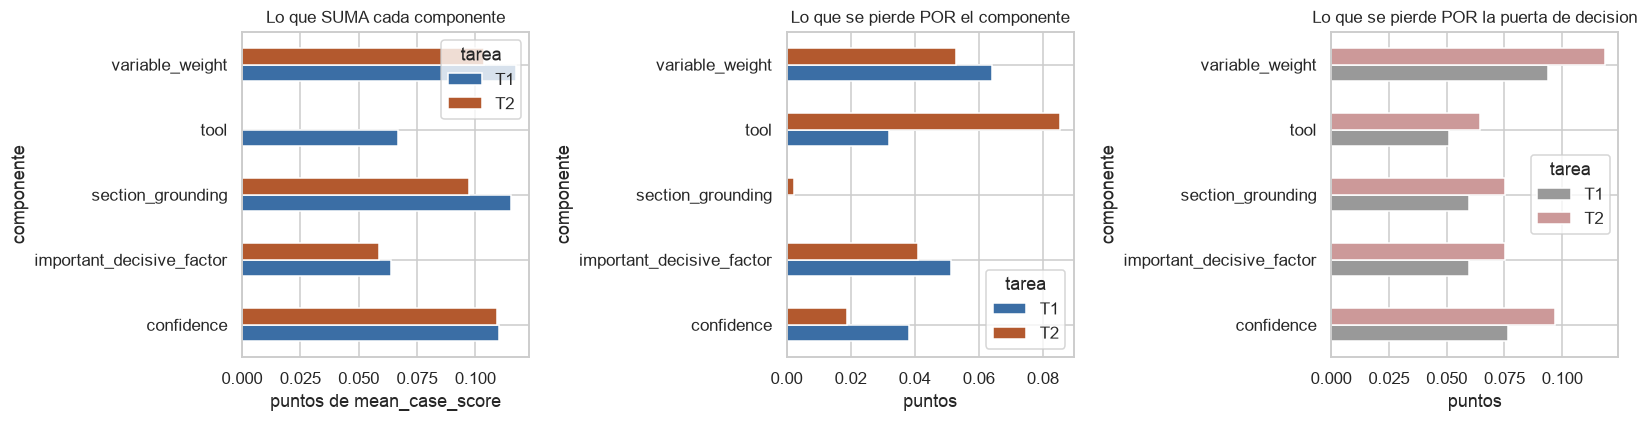

Techo si SOLO se arregla la puerta (manteniendo la calidad actual del resto):
  T1: puerta 65.9% · mean_case entre los que pasan 0.7180
      mean_case actual 0.4734 -> con puerta perfecta 0.7180   (ranking_score pasaria de 0.6268 a ~0.8590)
  T2: puerta 56.9% · mean_case entre los que pasan 0.6480
      mean_case actual 0.3690 -> con puerta perfecta 0.6480   (ranking_score pasaria de 0.4457 a ~0.8240)


In [79]:
# --- 4.3 Donde se pierden los puntos -------------------------------------
comp_t12 = []
for t in (1, 2):
    d = FILAS[t]
    pasa = d[d['decision_score'] == 1.0]
    tasa = len(pasa) / len(d)
    for k, w in PESOS_SIN_JUEZ.items():
        v = pasa[k].dropna().mean() if len(pasa) else 0.0
        comp_t12.append({'tarea': f'T{t}', 'componente': k.replace('_score', ''), 'media (casos que pasan)': v,
                         'peso': w, 'aporta al mean_case_score': v * w * tasa,
                         'pierde por el componente': (1 - v) * w * tasa,
                         'pierde por la puerta': w * (1 - tasa)})
CT = pd.DataFrame(comp_t12)
display(CT.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
piv = CT.pivot_table(index='componente', columns='tarea',
                     values=['aporta al mean_case_score', 'pierde por el componente', 'pierde por la puerta'])
piv['aporta al mean_case_score'].plot.barh(ax=axes[0], color=[PAL[1], PAL[2]])
axes[0].set_title('Lo que SUMA cada componente'); axes[0].set_xlabel('puntos de mean_case_score')
piv['pierde por el componente'].plot.barh(ax=axes[1], color=[PAL[1], PAL[2]])
axes[1].set_title('Lo que se pierde POR el componente'); axes[1].set_xlabel('puntos')
piv['pierde por la puerta'].plot.barh(ax=axes[2], color=['#999999', '#cc9999'])
axes[2].set_title('Lo que se pierde POR la puerta de decision'); axes[2].set_xlabel('puntos')
plt.show()

print('Techo si SOLO se arregla la puerta (manteniendo la calidad actual del resto):')
for t in (1, 2):
    d = FILAS[t]; pasa = d[d['decision_score'] == 1.0]
    media_pasa = pasa['case_score'].mean()
    tasa = len(pasa) / len(d)
    f1 = AGREGADOS[t].get('decision_f1_yes') or AGREGADOS[t].get('decision_weighted_f1')
    print(f'  T{t}: puerta {tasa:.1%} · mean_case entre los que pasan {media_pasa:.4f}')
    print(f'      mean_case actual {d["case_score"].mean():.4f} -> con puerta perfecta {media_pasa:.4f}'
          f'   (ranking_score pasaria de {AGREGADOS[t]["ranking_score"]:.4f} a ~{(media_pasa + 1.0) / 2:.4f})')


T1 · cruce de confianza GT vs baseline


conf_pred,borderline,clear
conf_gt,,
borderline,1,17
clear,6,51
uncertain,1,14



T2 · cruce de confianza GT vs baseline


conf_pred,borderline,clear
conf_gt,,
borderline,3,11
clear,6,52


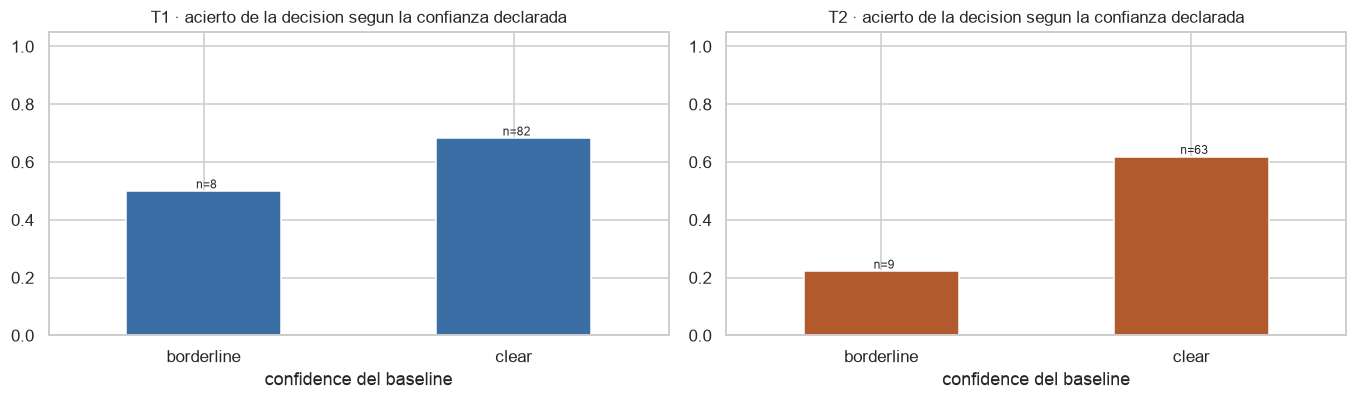


T1 · acuerdo por variable (0=not_used … 3=decisive). sesgo<0 = el baseline la infravalora


,n,sesgo,mae,gt_medio,pred_medio
variable,,,,,
pirads,90,0.430000,0.500000,2.470000,2.900000
comorbidity,90,-0.670000,0.760000,0.840000,0.180000
psa,90,0.700000,0.790000,1.760000,2.460000
fh,90,-0.560000,0.800000,0.780000,0.220000
vol,90,-0.800000,0.890000,1.180000,0.380000
psad,90,-0.230000,0.900000,1.290000,1.060000
dre,90,-1.220000,1.220000,1.270000,0.040000
age,90,-1.220000,1.330000,1.680000,0.460000
cspca,88,1.800000,1.820000,0.450000,2.250000



T2 · acuerdo por variable (0=not_used … 3=decisive). sesgo<0 = el baseline la infravalora


,n,sesgo,mae,gt_medio,pred_medio
variable,,,,,
bx_isup,52,-0.190000,0.620000,2.380000,2.190000
psa,72,0.680000,0.740000,1.830000,2.510000
fh,72,-0.640000,0.750000,0.830000,0.190000
ct,72,-0.320000,0.960000,1.290000,0.970000
pirads,72,0.990000,1.010000,1.740000,2.720000
comorbidity,72,-0.900000,1.010000,1.280000,0.380000
bx_gl_prim,52,0.750000,1.060000,1.290000,2.040000
psad,72,-0.060000,1.110000,0.920000,0.860000
bx_gl_sec,52,-0.020000,1.130000,1.370000,1.350000


In [80]:
# --- 4.4 Calibracion de la confianza y acuerdo en los pesos de variables --
def leer_razonamientos(task, fuente):
    salida = {}
    for cid in casos(task, 'ground_truth'):
        r = (gt_de(task, cid) if fuente == 'gt' else pred_de(task, cid))
        if r: salida[cid] = r['razonamiento']
    return salida

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
for ax, t in zip(axes, (1, 2)):
    gtr, prr = leer_razonamientos(t, 'gt'), leer_razonamientos(t, 'pred')
    comunes = [c for c in gtr if c in prr]
    d = pd.DataFrame([{'case_id': c, 'conf_gt': gtr[c].get('confidence'), 'conf_pred': prr[c].get('confidence'),
                       'acierta': FILAS[t].set_index('case_id').loc[c, 'decision_score'] == 1.0} for c in comunes])
    cal = d.groupby('conf_pred').agg(casos=('case_id', 'count'), acierto=('acierta', 'mean'))
    cal['acierto'].plot.bar(ax=ax, color=PAL[t])
    for i, (idx, fila) in enumerate(cal.iterrows()):
        ax.text(i, fila['acierto'], f'  n={int(fila["casos"])}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'T{t} · acierto de la decision segun la confianza declarada'); ax.set_ylim(0, 1.05)
    ax.set_xlabel('confidence del baseline'); ax.tick_params(axis='x', rotation=0)
    print(f'\nT{t} · cruce de confianza GT vs baseline')
    display(pd.crosstab(d['conf_gt'], d['conf_pred']))
plt.show()

# Acuerdo por variable (distancia ordinal, la misma escala que usa el evaluador)
ORD = {'not_used': 0, 'noted': 1, 'important': 2, 'decisive': 3}
for t in (1, 2):
    gtr, prr = leer_razonamientos(t, 'gt'), leer_razonamientos(t, 'pred')
    filas = []
    for c in [c for c in gtr if c in prr]:
        gw, pw = gtr[c].get('variable_weights', {}), prr[c].get('variable_weights', {})
        for v in set(gw) | set(pw):
            if gw.get(v) in ORD and pw.get(v) in ORD:
                filas.append({'variable': v, 'gt': ORD[gw[v]], 'pred': ORD[pw[v]]})
    dv = pd.DataFrame(filas)
    dv['error'] = dv['pred'] - dv['gt']
    agr = dv.groupby('variable').agg(n=('error', 'size'), sesgo=('error', 'mean'),
                                     mae=('error', lambda s: s.abs().mean()),
                                     gt_medio=('gt', 'mean'), pred_medio=('pred', 'mean')).sort_values('mae')
    caja(f'T{t} · acuerdo por variable (0=not_used … 3=decisive). sesgo<0 = el baseline la infravalora')
    display(agr.round(2).style.background_gradient('Reds', subset=['mae']))

T1 · coste medio implicito segun la tabla del prompt de sistema: €74.3 (presupuesto sugerido: €60-120) · mediana reveals baseline 5 vs urologo 3
T2 · coste medio implicito segun la tabla del prompt de sistema: €87.4 (presupuesto sugerido: €80-150) · mediana reveals baseline 5 vs urologo 0


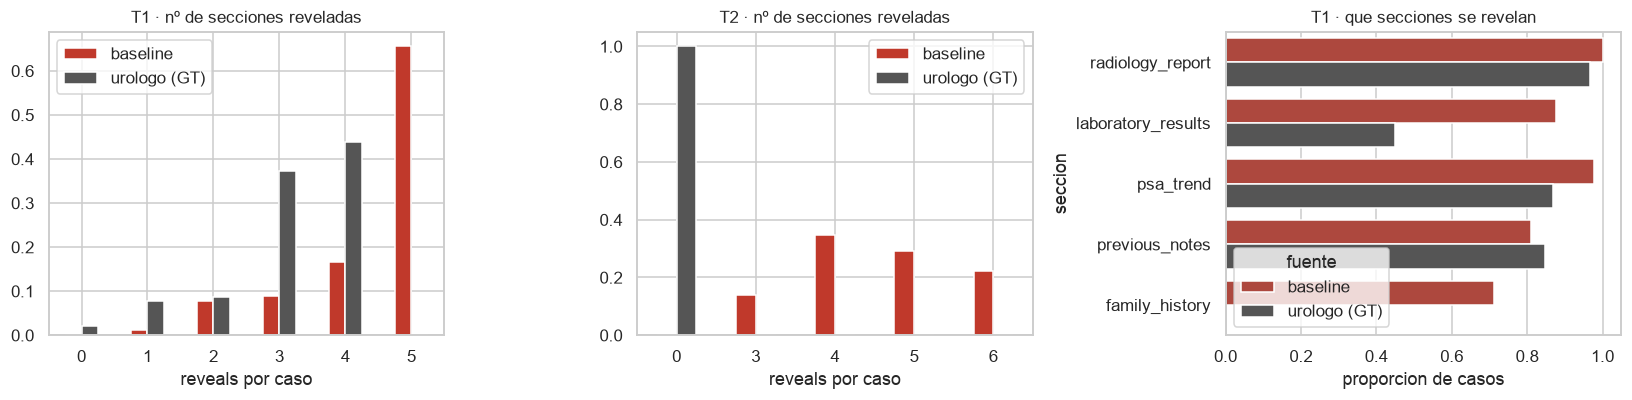


tool_score (precision de las revelaciones) por tarea:
  T1: media 0.6756 sobre 60 casos que pasan la puerta
  T2: media 0.0000 sobre 41 casos que pasan la puerta
  T2 sale 0.0000 por el artefacto de datos: las 72 reveal_sequence del ground truth local estan vacias,
  asi que la interseccion es vacia por construccion. No optimizar contra ese cero.


fuente,baseline
seccion,
family_history,0.75
laboratory_results,0.44
pathology_report,0.89
previous_notes,0.56
psa_trend,0.97
radiology_report,0.99


In [81]:
# --- 4.5 Herramientas: cuanto pide el agente y cuanto cuesta -------------
COSTE = {'get_psa_trend': 5, 'get_lab_results': 10, 'get_previous_notes': 15, 'get_mri_report': 20,
         'get_pathology_report': 22.5, 'get_family_history': 40, 'search_guidelines': 2}
SECCION_A_TOOL = {'psa_trend': 'get_psa_trend', 'laboratory_results': 'get_lab_results',
                  'previous_notes': 'get_previous_notes', 'radiology_report': 'get_mri_report',
                  'pathology_report': 'get_pathology_report', 'family_history': 'get_family_history'}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for i, t in enumerate((1, 2)):
    prr = leer_razonamientos(t, 'pred'); gtr = leer_razonamientos(t, 'gt')
    n_pred = pd.Series([len(prr[c].get('reveal_sequence') or []) for c in prr])
    n_gt = pd.Series([len(gtr[c].get('reveal_sequence') or []) for c in gtr])
    pd.DataFrame({'baseline': n_pred.value_counts(normalize=True),
                  'urologo (GT)': n_gt.value_counts(normalize=True)}).sort_index().plot.bar(
        ax=axes[i], color=[PAL['pred'], PAL['gt']])
    axes[i].set_title(f'T{t} · nº de secciones reveladas'); axes[i].set_xlabel('reveals por caso')
    axes[i].tick_params(axis='x', rotation=0)
    coste = [sum(COSTE.get(SECCION_A_TOOL.get(s, ''), 0) for s in (prr[c].get('reveal_sequence') or [])) for c in prr]
    print(f'T{t} · coste medio implicito segun la tabla del prompt de sistema: €{np.mean(coste):.1f} '
          f'(presupuesto sugerido: €{"60-120" if t == 1 else "80-150"}) · mediana reveals baseline '
          f'{n_pred.median():.0f} vs urologo {n_gt.median():.0f}')

frec = []
for t in (1, 2):
    prr, gtr = leer_razonamientos(t, 'pred'), leer_razonamientos(t, 'gt')
    for fuente, dic in (('baseline', prr), ('urologo (GT)', gtr)):
        cuenta = collections.Counter(s for c in dic for s in (dic[c].get('reveal_sequence') or []))
        for s, n in cuenta.items():
            frec.append({'tarea': f'T{t}', 'fuente': fuente, 'seccion': s, 'frecuencia': n / len(dic)})
F = pd.DataFrame(frec)
sns.barplot(F[F.tarea == 'T1'], y='seccion', x='frecuencia', hue='fuente', ax=axes[2],
            palette=[PAL['pred'], PAL['gt']])
axes[2].set_title('T1 · que secciones se revelan'); axes[2].set_xlabel('proporcion de casos')
plt.show()

print('\ntool_score (precision de las revelaciones) por tarea:')
for t in (1, 2):
    ts = FILAS[t]['tool_score'].dropna()
    print(f'  T{t}: media {ts.mean():.4f} sobre {len(ts)} casos que pasan la puerta')
print('  T2 sale 0.0000 por el artefacto de datos: las 72 reveal_sequence del ground truth local estan vacias,')
print('  asi que la interseccion es vacia por construccion. No optimizar contra ese cero.')
display(F[F.tarea == 'T2'].pivot_table(index='seccion', columns='fuente', values='frecuencia').fillna(0).round(2))

event predicho por el baseline: {0.0: 73, nan: 2}
event en el ground truth      : {0: 56, 1: 19}

HALLAZGO ESTRUCTURAL: Task3Output no tiene campo event, y run.py escribe
    {"event": structured.get("event", 0), ...}  ->  el baseline entrega event=0 SIEMPRE.
   Por eso mean_event_score = 0.7397, que es exactamente la
   proporcion de censurados (74.7%): es la tasa base, no una prediccion.


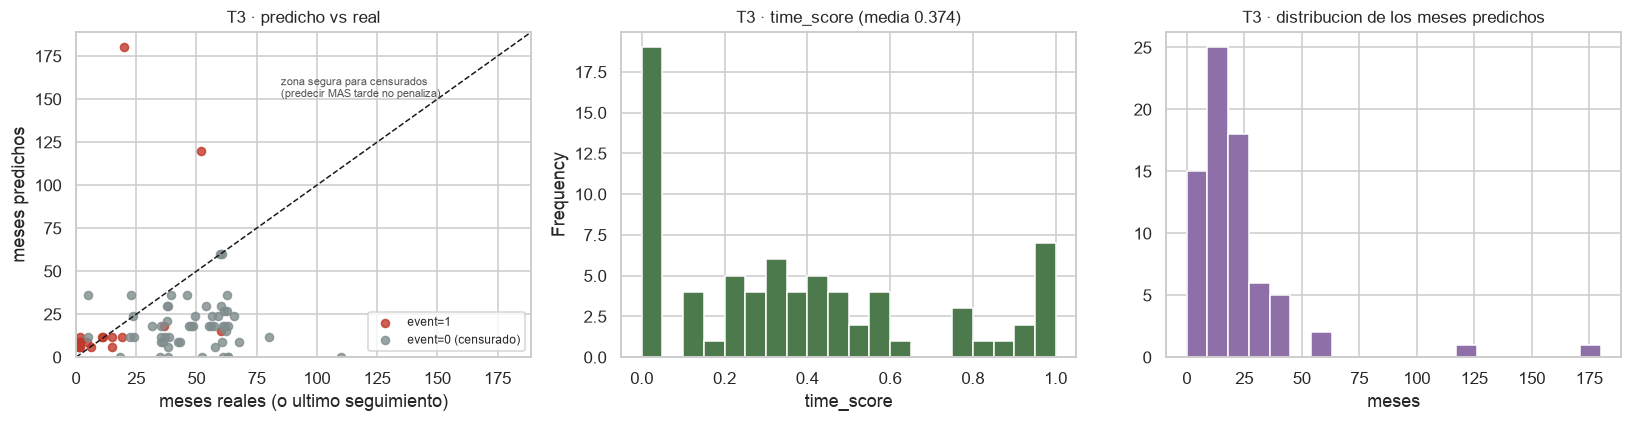


meses predichos: mediana 12.0 · rango [0, 180] · unicos 14
meses reales   : mediana 38.5 · rango [1, 110]
MAE sobre los event=1: 19.5 meses

Comparacion con predictores triviales (mismo evaluador, mismos 75 casos):


predictor,mean_time_score,ranking_score (c-index),mean_case_score
mediana global (38 m),0.6296,0.5000,0.6881
mediana de censurados (49 m),0.7057,0.5000,0.7262
constante 60 meses (60 m),0.7590,0.5000,0.7528
constante 120 meses (120 m),0.7468,0.5000,0.7468
BASELINE (LLM),0.3738,0.6823,0.5419


Lectura, que es menos halagadora de lo que parece:
 · En mean_case_score una CONSTANTE de 60 meses (0.75) DUPLICA holgadamente al baseline (0.54),
   porque en el 75% censurado basta predecir tarde para puntuar 1.0 en time_score.
   Es decir: la estimacion de meses del LLM es hoy peor que no estimar nada.
 · Pero el ranking de T3 es el c-index, y ahi la constante vale 0.5 (todo empatado) frente al
   0.6823 del baseline: el LLM SI ordena el riesgo, y eso es lo que rankea.
 · Conclusion operativa: en T3 la palanca de leaderboard es ORDENAR mejor (c-index), no calibrar
   la magnitud; y como suelo, conviene un valor de respaldo tardio para no perder casos.

Casos T3 sin salida (2): ['T3-038', 'T3-063']
  · T3-038: event=0 months=48.9
    patologia quirurgica: The robot-assisted radical prostatectomy specimen showed Gleason 3+4 (ISUP grade group 2),
      pathological stage pT2c. There was no extraprostatic extension; surgical margins were
      positive; the seminal vesicles were not inv

In [82]:
# --- 4.6 Tarea 3 en detalle ---------------------------------------------
d3 = FILAS[3].copy()
print('event predicho por el baseline:', d3['pred_event'].value_counts(dropna=False).to_dict())
print('event en el ground truth      :', d3['gt_event'].value_counts(dropna=False).to_dict())
print('\nHALLAZGO ESTRUCTURAL: Task3Output no tiene campo event, y run.py escribe')
print('    {"event": structured.get("event", 0), ...}  ->  el baseline entrega event=0 SIEMPRE.')
print(f'   Por eso mean_event_score = {AGREGADOS[3]["mean_event_score"]:.4f}, que es exactamente la')
print(f'   proporcion de censurados ({100 * (d3["gt_event"] == 0).mean():.1f}%): es la tasa base, no una prediccion.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ok = d3.dropna(subset=['pred_months'])
for ev_, col, lab in [(1, '#c0392b', 'event=1'), (0, '#7f8c8d', 'event=0 (censurado)')]:
    s = ok[ok.gt_event == ev_]
    axes[0].scatter(s['gt_months'], s['pred_months'], c=col, label=lab, alpha=.8, s=28)
lim = [0, max(ok['gt_months'].max(), ok['pred_months'].max()) * 1.05]
axes[0].plot(lim, lim, 'k--', lw=1); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('meses reales (o ultimo seguimiento)'); axes[0].set_ylabel('meses predichos')
axes[0].set_title('T3 · predicho vs real'); axes[0].legend(fontsize=8)
axes[0].annotate('zona segura para censurados\n(predecir MAS tarde no penaliza)',
                 xy=(lim[1] * .45, lim[1] * .8), fontsize=7, color='#555555')

ok['time_score'].plot.hist(bins=20, ax=axes[1], color=PAL[3])
axes[1].set_title(f'T3 · time_score (media {ok["time_score"].mean():.3f})'); axes[1].set_xlabel('time_score')

axes[2].hist(ok['pred_months'], bins=20, color='#8e6fa8')
axes[2].set_title('T3 · distribucion de los meses predichos'); axes[2].set_xlabel('meses')
plt.show()

print(f'\nmeses predichos: mediana {ok["pred_months"].median():.1f} · rango '
      f'[{ok["pred_months"].min():.0f}, {ok["pred_months"].max():.0f}] · unicos {ok["pred_months"].nunique()}')
print(f'meses reales   : mediana {ok["gt_months"].median():.1f} · rango '
      f'[{ok["gt_months"].min():.0f}, {ok["gt_months"].max():.0f}]')
print(f'MAE sobre los event=1: {AGREGADOS[3]["event1_time_mae_months"]:.1f} meses')

# Cuanto de ese resultado es merito del LLM: comparacion con predictores triviales
def evaluar_constante(valor):
    filas = [EV.evaluate_recurrence_case(g, {'case_id': cid, 'months_to_recurrence': float(valor), 'event': 0}, None)
             for cid, g in GT_REGISTROS[3].items()]
    a = EV.aggregate_recurrence_metrics(filas)
    return a['mean_time_score'], a['ranking_score'], a['mean_case_score']

print('\nComparacion con predictores triviales (mismo evaluador, mismos 75 casos):')
tabla = []
for nombre, val in [('mediana global', d3['gt_months'].median()),
                    ('mediana de censurados', d3[d3.gt_event == 0]['gt_months'].median()),
                    ('constante 60 meses', 60), ('constante 120 meses', 120)]:
    ts, rk, mc = evaluar_constante(val)
    tabla.append({'predictor': f'{nombre} ({val:.0f} m)', 'mean_time_score': ts,
                  'ranking_score (c-index)': rk, 'mean_case_score': mc})
tabla.append({'predictor': 'BASELINE (LLM)', 'mean_time_score': AGREGADOS[3]['mean_time_score'],
              'ranking_score (c-index)': AGREGADOS[3]['ranking_score'],
              'mean_case_score': AGREGADOS[3]['mean_case_score']})
display(pd.DataFrame(tabla).style.hide(axis='index').format(
    {'mean_time_score': '{:.4f}', 'ranking_score (c-index)': '{:.4f}', 'mean_case_score': '{:.4f}'}, na_rep='—'))
print('Lectura, que es menos halagadora de lo que parece:')
print(' · En mean_case_score una CONSTANTE de 60 meses (0.75) DUPLICA holgadamente al baseline (0.54),')
print('   porque en el 75% censurado basta predecir tarde para puntuar 1.0 en time_score.')
print('   Es decir: la estimacion de meses del LLM es hoy peor que no estimar nada.')
print(' · Pero el ranking de T3 es el c-index, y ahi la constante vale 0.5 (todo empatado) frente al')
print(f'   {AGREGADOS[3]["ranking_score"]:.4f} del baseline: el LLM SI ordena el riesgo, y eso es lo que rankea.')
print(' · Conclusion operativa: en T3 la palanca de leaderboard es ORDENAR mejor (c-index), no calibrar')
print('   la magnitud; y como suelo, conviene un valor de respaldo tardio para no perder casos.')

perdidos = sorted(set(GT_REGISTROS[3]) - set(PRED_PLANAS[3]))
print(f'\nCasos T3 sin salida ({len(perdidos)}): {perdidos}')
for cid in perdidos:
    g = GT_REGISTROS[3][cid]
    print(f'  · {cid}: event={g.get("event")} months={g.get("months_to_recurrence")}')
    sp = clinico_de(3, cid) or {}
    print('    patologia quirurgica:', envolver((sp.get("surgical_pathology_report") or "")[:280], 96, '      ').strip())
print('\nCausa: el modelo devuelve un centinela ("Cannot be determined" / -1 / "N/A") en vez de un numero,')
print('Task3Output lo rechaza (ge=0.0), form_fill agota los reintentos y LANZA. En Grand Challenge cada caso')
print('es un contenedor, asi que no arrastra a los demas — pero ese caso no entrega y no puntua.')

In [83]:
# --- 4.7 Catalogo de fallos y sesgo sistematico -------------------------
for t in (1, 2):
    d = FILAS[t].merge(pd.DataFrame([{'case_id': c, **{k: prompt_de(t, c).get(k) for k in
                        ('pirads', 'psa', 'psad', 'cspca', 'age', 'dre', 'bx')}} for c in casos(t, 'ground_truth')]),
                       on='case_id', how='left')
    caja(f'T{t} · fallos de la puerta cruzados con las variables de entrada')
    d['falla'] = d['decision_score'] != 1.0
    print('por PI-RADS:')
    display(d.pivot_table(index='pirads', columns='gt_decision', values='falla',
                          aggfunc=['mean', 'count']).round(2))
    print('por prob. csPCa (terciles):')
    d['cspca_bin'] = pd.qcut(pd.to_numeric(d['cspca'], errors='coerce'), 3, duplicates='drop')
    display(d.pivot_table(index='cspca_bin', values='falla', aggfunc=['mean', 'count'], observed=True).round(2))
    peores = d.nsmallest(5, 'case_score')[['case_id', 'gt_decision', 'pred_decision', 'case_score', 'pirads', 'psa', 'cspca']]
    print('5 peores casos:'); display(peores.style.hide(axis='index'))
    for cid in peores['case_id'].head(3):
        pr = pred_de(t, cid)
        if pr is None:
            print(f'\n  {cid}: CASO PERDIDO — el baseline no entrego salida para este caso.')
            continue
        print(f'\n  free_text del baseline en {cid} (GT={gt_de(t, cid)["decision"]}, pred={pr["decision"]}):')
        print(envolver(pr['razonamiento'].get('free_text'), 100, '     '))


T1 · fallos de la puerta cruzados con las variables de entrada
por PI-RADS:


mean       count      
gt_decision   no   yes    no   yes
pirads                            
2            0.4   NaN   5.0   NaN
3            0.8  0.00   5.0   2.0
4            1.0  0.00   9.0  24.0
5            1.0  0.03  15.0  30.0
NA           0.0   NaN   1.0   NaN

por prob. csPCa (terciles):


,mean,count
,falla,falla
cspca_bin,,
"(-0.001, 0.751]",0.39,31
"(0.751, 0.843]",0.23,30
"(0.843, 0.972]",0.40,30


5 peores casos:


...

por prob. csPCa (terciles):


,mean,count
,falla,falla
cspca_bin,,
"(-0.001, 0.74]",0.58,24
"(0.74, 0.83]",0.46,24
"(0.83, 0.972]",0.25,24


5 peores casos:


case_id,gt_decision,pred_decision,case_score,pirads,psa,cspca
T2-006,active_surveillance,active_treatment,0.000000,5,13.500000,0.894703
T2-007,active_treatment,continued_surveillance,0.000000,4,13.200000,0.635189
T2-008,active_surveillance,active_treatment,0.000000,4,6.800000,0.829528
T2-009,active_surveillance,continued_surveillance,0.000000,3,8.700000,0.873566
T2-016,active_surveillance,active_treatment,0.000000,5,13.600000,0.838819



  free_text del baseline en T2-006 (GT=active_surveillance, pred=active_treatment):
     The decision to recommend active treatment is driven primarily by the convergence of a PI-RADS
     5 finding, a high PSA velocity (3.11 ng/mL/yr), and an extremely high csPCa predicted
     probability (0.8947), which mandates intervention despite prior low-grade pathology.

  free_text del baseline en T2-007 (GT=active_treatment, pred=continued_surveillance):
     The decision is driven by the combination of the significantly rising PSA (13.2 ng/mL) and the
     presence of a PI-RADS 4 lesion, tempered by the confirmed low-risk ISUP GG2 pathology, leading
     to an escalation of active surveillance.

  free_text del baseline en T2-008 (GT=active_surveillance, pred=active_treatment):
     The decision is driven primarily by the PI-RADS 4 finding on mpMRI, the elevated current PSA
     (6.8 ng/mL), the history of prior cancer, and the need for definitive local staging to guide
     management.


In [84]:
# --- 4.8 ¿Hay senal en los embeddings congelados que el baseline ignora? --
# Sonda rapida (regresion logistica con validacion cruzada) sobre los vectores
# que el reto nos da y el baseline nunca abre. NO es un modelo final: n es
# pequeno, no hay conjunto de test aparte y la CV no esta anidada.
if EJECUTAR_SONDA_EMBEDDINGS:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    def matriz(task, origenes):
        X, ids = [], []
        for cid in casos(task, 'ground_truth'):
            e = emb_bruto_de(task, cid) or {}
            trozos = []
            for o in origenes:
                vs = e.get(o) or []
                if not vs: trozos = None; break
                trozos.append(np.mean(np.array(vs, dtype=float), axis=0))
            if trozos: X.append(np.concatenate(trozos)); ids.append(cid)
        return np.array(X), ids

    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    modelo_sonda = lambda C: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=C))
    resultados = []

    X1, ids1 = matriz(1, ['MRI image'])
    y1 = np.array([1 if gt_de(1, c)['decision'] == 'yes' else 0 for c in ids1])
    auc1 = cross_val_score(modelo_sonda(0.1), X1, y1, cv=cv, scoring='roc_auc')
    resultados.append({'tarea': 'T1 · biopsia si/no', 'origenes': 'MRI', 'n': len(ids1), 'dim': X1.shape[1],
                       'AUC CV': auc1.mean(), 'sd': auc1.std()})

    X2, ids2 = matriz(2, ['MRI image', 'Biopsy slide'])
    y2 = np.array([1 if gt_de(2, c)['decision'] == 'active_treatment' else 0 for c in ids2])
    auc2 = cross_val_score(modelo_sonda(0.05), X2, y2, cv=cv, scoring='roc_auc')
    resultados.append({'tarea': 'T2 · tratamiento activo vs resto', 'origenes': 'MRI+biopsia', 'n': len(ids2),
                       'dim': X2.shape[1], 'AUC CV': auc2.mean(), 'sd': auc2.std()})

    X3, ids3 = matriz(3, ['MRI image', 'Prostatectomy slide'])
    y3 = np.array([gt_de(3, c)['decision']['event'] for c in ids3])
    auc3 = cross_val_score(modelo_sonda(0.05), X3, y3, cv=cv, scoring='roc_auc')
    resultados.append({'tarea': 'T3 · event 0/1', 'origenes': 'MRI+prostatectomia', 'n': len(ids3),
                       'dim': X3.shape[1], 'AUC CV': auc3.mean(), 'sd': auc3.std()})

    display(pd.DataFrame(resultados).style.hide(axis='index').format({'AUC CV': '{:.3f}', 'sd': '{:.3f}'}))
    print('Lectura prudente (con las advertencias de arriba muy presentes):')
    print(' · T1: los embeddings de MRI NO predicen la decision de biopsia (AUC ~0.41, peor que el azar).')
    print('   Esa decision la llevan las variables clinicas (PI-RADS, PSA, csPCa), que ya estan en el prompt.')
    print(' · T2: el par MRI+biopsia separa bastante bien "tratamiento activo vs resto" (AUC ~0.80 en CV).')
    print('   Es el hallazgo mas prometedor de esta celda: T2 es la tarea mas debil del baseline')
    print(f'   (ranking {AGREGADOS[2]["ranking_score"]:.4f}) y su puerta falla el')
    print(f'   {100 * (1 - FILAS[2]["decision_score"].eq(1.0).mean()):.0f}% de las veces, mientras los vectores')
    print('   que el reto ya nos da y el baseline nunca abre traen senal sobre justo ese corte.')
    print(' · T3: MRI+prostatectomia da AUC ~0.65 sobre el evento — util para DERIVAR event (hoy constante 0)')
    print('   y para ordenar riesgo, que es lo que rankea T3.')
    print(' · Compara siempre contra la tasa base:', {f'T{t}': round(float(np.mean(y)), 3)
          for t, y in ((1, y1), (2, y2), (3, y3))})
    print(' · Nada de esto es un resultado final: n pequeno, CV no anidada, sin conjunto de test aparte.')
    print('   Es una sonda para decidir DONDE invertir, no un modelo.')
else:
    print('EJECUTAR_SONDA_EMBEDDINGS = False')

tarea,origenes,n,dim,AUC CV,sd
T1 · biopsia si/no,MRI,89,1024,0.409,0.052
T2 · tratamiento activo vs resto,MRI+biopsia,68,1984,0.805,0.150
T3 · event 0/1,MRI+prostatectomia,75,1984,0.649,0.116


Lectura prudente (con las advertencias de arriba muy presentes):
 · T1: los embeddings de MRI NO predicen la decision de biopsia (AUC ~0.41, peor que el azar).
   Esa decision la llevan las variables clinicas (PI-RADS, PSA, csPCa), que ya estan en el prompt.
 · T2: el par MRI+biopsia separa bastante bien "tratamiento activo vs resto" (AUC ~0.80 en CV).
   Es el hallazgo mas prometedor de esta celda: T2 es la tarea mas debil del baseline
   (ranking 0.4457) y su puerta falla el
   43% de las veces, mientras los vectores
   que el reto ya nos da y el baseline nunca abre traen senal sobre justo ese corte.
 · T3: MRI+prostatectomia da AUC ~0.65 sobre el evento — util para DERIVAR event (hoy constante 0)
   y para ordenar riesgo, que es lo que rankea T3.
 · Compara siempre contra la tasa base: {'T1': 0.607, 'T2': 0.456, 'T3': 0.253}
 · Nada de esto es un resultado final: n pequeno, CV no anidada, sin conjunto de test aparte.
   Es una sonda para decidir DONDE invertir, no un modelo.


## Analisis del Agente

Quieor un analisis completo del agente base, este como se comporta, como funcionan sus prompts, a que herramientas recurre, como usa mcps, que conexiones logra, como esta conectado a langgraph, que erramienta usa de la base que nosotros podamos usar y que este en la dcumentaccionlema oficial del challenge, todo con el fin de entender mejor el problema y ejecutar mi diseñar mi solucion.

---

| | Que se mira |
|---|---|
| **5.1** | arquitectura: grafo LangGraph, estado, enrutado, orden de ejecucion de `run.py` e `inference.py` |
| **5.2** | los prompts: sistema, plantilla por caso, y el del `form_fill` |
| **5.3** | lectura critica de esos prompts |
| **5.4** | herramientas y MCP: como se lanza el servidor, registros por tarea, esquemas, predictor opcional |
| **5.5** | RAG de guias EAU: que hay indexado y que devuelve de verdad |
| **5.6** | capa de modelo, configuracion Hydra y el contrato del contenedor de Grand Challenge |
| **5.7** | trazabilidad: que se guarda y que se tira |

In [85]:
# --- 5.1 Arquitectura ----------------------------------------------------
print('GRAFO (agent/graph.py)')
if EJECUTAR_MCP_EN_VIVO:
    print(grafo.get_graph().draw_ascii())
    print('\nMermaid (para pegarlo en la memoria del reto):')
    print(grafo.get_graph().draw_mermaid())
print('\nEstado compartido (AgentState):')
for k, v in AgentState.__annotations__.items():
    print(f'  · {k:22} {v}')

print('\nORDEN DE EJECUCION REAL (run.py)')
for linea in [
    'main()',
    ' |- start_embedding_service(paths.embedding_model_dir)   # subproceso con el modelo de embeddings + socket unix',
    ' \\- run_agent(cfg)',
    '     |- load_model(cfg)                                  # el LLM se carga UNA vez y se reutiliza en las 3 tareas',
    '     |- build_system_prompt()',
    '     \\- por cada tarea:',
    '         |- load_cases(data/task<N>/agent_input)          # renderiza el prompt con Jinja',
    '         |- MultiServerMCPClient(...).get_tools()         # arranca el servidor MCP (stdio) de ESA tarea',
    '         |- create_graph(tools, model, system_prompt)',
    '         \\- por cada caso: graph.ainvoke(...) -> _write_task_outputs()',
]:
    print('  ' + linea)
print('Dos detalles que importan:')
print(' · graph.ainvoke NO esta envuelto en try/except: una excepcion en un caso (p.ej. form_fill que lanza)')
print('   se lleva por delante el resto de la cola local. En Grand Challenge cada caso es un contenedor')
print('   independiente, asi que ahi solo se pierde ese caso.')
print(' · recursion_limit = agent.max_iterations (configs/config.yaml) — el tope de pasos del bucle ReAct.')

GRAFO (agent/graph.py)
        +-----------+            
        | __start__ |            
        +-----------+            
              *                  
              *                  
              *                  
          +-------+              
          | agent |              
          +-------+              
         ..        ..            
       ..            ..          
      .                .         
+-------+         +-----------+  
| tools |         | form_fill |  
+-------+         +-----------+  
                        *        
                        *        
                        *        
                   +---------+   
                   | __end__ |   
                   +---------+   

Mermaid (para pegarlo en la memoria del reto):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	form_fill(form_fill)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> f

In [86]:
# --- 5.2 Los prompts, literales -----------------------------------------
from chimera_agent_baseline.agent.prompts import SYSTEM_PROMPT
caja('PROMPT DE SISTEMA (agent/prompts.py) — identico para las tres tareas')
print(SYSTEM_PROMPT)
print(f'[{len(SYSTEM_PROMPT)} caracteres · ~{len(SYSTEM_PROMPT) // 4} tokens]')

caja('PLANTILLA DEL PROMPT POR CASO (templates/prompts/agent_prompt.j2)')
print((REPO / 'templates' / 'prompts' / 'agent_prompt.j2').read_text())


PROMPT DE SISTEMA (agent/prompts.py) — identico para las tres tareas
You are a clinical decision-support agent for prostate cancer diagnostics.

You see the patient encounter context up front (vitals, headline PSA, chief complaint, physical-exam prose, social context, etc.). Anything beyond that — laboratory panels, imaging reports, pathology, prior notes, family history — lives behind a tool and must be actively requested. The full set of available tools, including their schemas and what each returns, is delivered separately by the runtime; trust those descriptions over any list you may recall from elsewhere.

## Calling tools — be selective

Each tool call has a real-world cost (EHR retrieval, lab-system queries, patient-interview minutes, radiology / pathology reading time). The realistic per-call costs in this baseline are:

| Tool                   | Cost  | What it covers |
|------------------------|-------|----------------|
| `search_guidelines`    | ~€2   | semantic DB query +

### 5.3 Lectura critica de los prompts

**a) El prompt de sistema es un protocolo de coste.** Da una tabla de precios en euros por herramienta
(`get_family_history` €40, `get_mri_report` €20, `search_guidelines` €2), un presupuesto por tarea (€60–120 en T1,
€80–150 en T2) y tres preguntas obligatorias antes de cada llamada. Es una implementacion directa de la metrica:
`tool_score` es **precision** de las revelaciones, asi que pedir de menos es gratis y pedir de mas cuesta.
La seccion 4.5 mide si el agente lo respeta.

**b) Es el mismo prompt para las tres tareas.** Menciona herramientas que en T3 no existen (`get_psa_trend`,
`get_lab_results`) y no menciona la que si existe (`get_surgical_pathology_report`). El catalogo real llega por
MCP, y el propio prompt avisa: *"trust those descriptions over any list you may recall"* — pero la tabla de costes
que el modelo lee sigue siendo la de T1/T2.

**c) El prompt de T3 nunca explica la censura.** La plantilla pregunta *"predict this patient's time to biochemical
recurrence, in months"*, pero el **74.7%** de los casos son censurados: para ellos `months_to_recurrence` es
*"tiempo hasta el ultimo seguimiento sin evento"*, no *"cuando recurre"*. El modelo ve patologia adversa, concluye
"va a recurrir", y ante "dime cuando" se niega con un centinela — que es exactamente el fallo que tumba T3-038 y
T3-063 (seccion 4.6). Es un problema de **enunciado**, no de formato: reintentar no cambia el criterio del modelo.

**d) El `form_fill` regenera la conversacion plana en cada reintento** (a proposito, para no despistar a modelos
pequenos), asi que el modelo nunca ve su intento anterior: solo el error de validacion pegado al final del mismo
prompt.

**e) La coherencia "no puntues lo que no consultaste" no se pide, se impone.** El prompt lo dice en prosa, pero
lo que realmente lo garantiza es el schema dinamico: `build_dynamic_model` solo incluye `fh` si se llamo a
`get_family_history`, y `extra="forbid"` rechaza cualquier clave extra.

In [87]:
# --- 5.4 Herramientas y MCP ---------------------------------------------
from chimera_agent_baseline.run import _mcp_args
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir

with initialize_config_dir(config_dir=str(REPO / 'configs'), version_base=None):
    CFG = compose(config_name='config', overrides=['+experiment=local_paths'])

print('Comando exacto con el que run.py arranca el servidor MCP (transporte stdio, un proceso por tarea):')
for t in (1, 2, 3):
    print(f'  task{t}:', sys.executable, ' '.join(_mcp_args(CFG, DATA / f'task{t}' / 'agent_input', f'task{t}')))
print('\nCon agent.predictor.enabled=true se anade --enable-predictor y aparece get_image_predictor.')

print('\nRegistros ToolSpec (definitions.py) -> campo del clinical-data que revela cada herramienta:')
reg = pd.DataFrame([{'tool': s.name, 'tarea': f'T{t}', 'campos': ', '.join(s.fields)}
                    for t, specs in REGISTROS.items() for s in specs])
display(reg.pivot_table(index=['tool', 'campos'], columns='tarea', values='campos', aggfunc=lambda x: 'si')
        .fillna('—'))

if EJECUTAR_MCP_EN_VIVO:
    print('\nComprobacion en vivo: mismo servidor con el predictor ENCENDIDO (tarea 3)')
    tools_pred = await cliente_mcp(3, con_predictor=True).get_tools()
    print('  herramientas:', [x.name for x in tools_pred])
    pt = [x for x in tools_pred if x.name == 'get_image_predictor'][0]
    print('  descripcion :', (pt.description or '').replace('\n', ' ')[:200])
    print('  invocacion  :', texto_tool(await pt.ainvoke({'case_id': CASOS_FOCO[3]})))
    print('  -> devuelve prediction=null: run_predictor es un STUB. Es el punto de extension previsto')
    print('     (recibe TODOS los embeddings del paciente y debe devolver solo un score compacto,')
    print('      nunca los vectores crudos, para no meter 1024 numeros en el contexto del LLM).')

Comando exacto con el que run.py arranca el servidor MCP (transporte stdio, un proceso por tarea):
  task1: /home/jjlondono/PycharmProjects/chimera-agent-baseline/.venv/bin/python -m chimera_agent_baseline.mcp_server --data-dir /home/jjlondono/PycharmProjects/chimera-agent-baseline/data/task1/agent_input --resource-dir resources --tool-registry task1
  task2: /home/jjlondono/PycharmProjects/chimera-agent-baseline/.venv/bin/python -m chimera_agent_baseline.mcp_server --data-dir /home/jjlondono/PycharmProjects/chimera-agent-baseline/data/task2/agent_input --resource-dir resources --tool-registry task2
  task3: /home/jjlondono/PycharmProjects/chimera-agent-baseline/.venv/bin/python -m chimera_agent_baseline.mcp_server --data-dir /home/jjlondono/PycharmProjects/chimera-agent-baseline/data/task3/agent_input --resource-dir resources --tool-registry task3

Con agent.predictor.enabled=true se anade --enable-predictor y aparece get_image_predictor.

Registros ToolSpec (definitions.py) -> campo 

,tarea,T1,T2,T3
tool,campos,,,
get_family_history,family_history,si,si,si
get_lab_results,laboratory_results,si,si,—
get_mri_report,radiology_report,si,si,si
get_pathology_report,pathology_report,—,si,si
get_previous_notes,previous_notes,si,si,si
get_psa_trend,psa_trend,si,si,—
get_surgical_pathology_report,surgical_pathology_report,—,—,si



Comprobacion en vivo: mismo servidor con el predictor ENCENDIDO (tarea 3)


  herramientas: ['get_mri_report', 'get_pathology_report', 'get_surgical_pathology_report', 'get_previous_notes', 'get_family_history', 'get_image_predictor', 'search_guidelines']
  descripcion : Run the image-embedding predictor over the patient's available embeddings (MRI / biopsy / prostatectomy, whichever are present) and return a compact score/label (not the raw vectors). Use it when the 
  invocacion  : {"case_id": "T3-001", "origins": {"MRI image": 1, "Biopsy slide": 2, "Prostatectomy slide": 3}, "prediction": null, "detail": "stub predictor \u2014 replace tools.predictor.run_predictor with your trained head"}
  -> devuelve prediction=null: run_predictor es un STUB. Es el punto de extension previsto
     (recibe TODOS los embeddings del paciente y debe devolver solo un score compacto,
      nunca los vectores crudos, para no meter 1024 numeros en el contexto del LLM).


In [88]:
# --- 5.5 RAG: la base de guias EAU --------------------------------------
import chromadb
cli = chromadb.PersistentClient(path=str(REPO / 'resources' / 'guidelines_db'))
col = cli.get_collection('guidelines')
print(f'Coleccion "guidelines": {col.count()} chunks')
muestra = col.peek(3)
for i, (doc, meta) in enumerate(zip(muestra['documents'], muestra['metadatas'])):
    print(f'\n--- chunk {i} · metadatos: {meta}')
    print(envolver(doc[:400], 100, '    '))

if EJECUTAR_RAG_EN_VIVO:
    from chimera_agent_baseline.rag import start_embedding_service, GuidelinesSearch
    svc_rag = start_embedding_service(CFG.paths.embedding_model_dir)
    try:
        gs = GuidelinesSearch(str(REPO / 'resources'))
        for q in ['Active surveillance eligibility for ISUP grade group 2 with cribriform pattern',
                  'PSA density threshold for biopsy in PI-RADS 3 lesions',
                  'Risk of biochemical recurrence after radical prostatectomy with positive margins']:
            caja(f'search_guidelines("{q}")')
            for h in gs.query(q, top_k=3):
                print(f'  score={h["score"]}  page={h["page"]}  section={str(h["section"])[:60]}')
                print(envolver(h['text'][:420], 98, '      '))
    finally:
        svc_rag.stop()
    print('\nDos cosas que se ven al ejecutarlo:')
    print(' · los pasajes recuperados SI son pertinentes (criterios de AS, patron cribiforme, DETECTIVE...),')
    print('   asi que el RAG aporta el texto correcto de la guia EAU 2026 que el reto nos licencia usar;')
    print(' · pero el campo "score" (1 - distancia L2 de Chroma) sale bajo o negativo y el "section" del')
    print('   metadato es texto arrastrado del chunk anterior: la calidad del CHUNKING y de los metadatos')
    print('   es mejorable, y hoy el LLM recibe esos metadatos ruidosos tal cual.')
else:
    print('\nEJECUTAR_RAG_EN_VIVO = False (arrancar el servicio carga el modelo de embeddings en CPU, ~30 s).')
print('\nArquitectura del RAG (rag.py): el modelo de embeddings vive en UN subproceso del proceso principal')
print('y los servidores MCP (que son procesos cortos) le piden vectores por un socket unix')
print(f'({os.environ.get("CHIMERA_EMBED_SOCKET", "/tmp/chimera_embed.sock")}) — asi no se recarga por llamada.')

Coleccion "guidelines": 1501 chunks

--- chunk 0 · metadatos: {'page': 1, 'section': ''}
    P. Cornford (Chair), D. Tilki (Vice-chair), R.C.N. van den Bergh,
    D. Eberli, V. Fonteyne, G. Gandaglia, S. Gillessen, A.M. Henry,
    G.J.L.H. van Leenders, J. Oldenburg, I. van Oort,
    D.E. Oprea-Lager, M. Roberts, O. Rouvière,
    M. De Santis, I.G. Schoots, J. Stranne, T. Wiegel
    Patient Advocates: E. Briers, B. Madsen
    Guidelines Associates: P. Chiu, A. Epure, A. Farolfi,
    N. Grivas, E. Linares Espinós, A.

--- chunk 1 · metadatos: {'page': 2, 'section': '1.4.2 Summary of changes'}
    METHODS
    2.1
    Data identification
    2.2
    Review
    2.3
    Future goals
    3.
    EPIDEMIOLOGY AND AETIOLOGY
    3.1
    Epidemiology
    3.2
    Aetiology and risk factors for prostate cancer
    3.2.1
    Hereditary risk factors for PCa
    3.2.1.a
    Ethnicity and Family history
    3.2.1.b
    Germline mutations
    3.2.1.c
    Genetic single nucleotide polymorphism (SNPs)
   

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 19980.45it/s]



search_guidelines("Active surveillance eligibility for ISUP grade group 2 with cribriform pattern")
  score=0.1538  page=88  section=20 years, with a number needed to treat to avert one PCa dea
      aiting in asymptomatic patients with life expectancy < 10 years (based on
      co-morbidities and age).
      Strong
      Offer active surveillance (AS) to selected patients with ISUP grade group (GG) 2 disease,
      e.g. < 10% pattern 4, PSA < 10 ng/mL, ≤ cT2a, low disease extent on imaging and low extent
      of tumour in biopsies (≤ 3 positive cores with ISUP GG 2 and ≤ 50% cancer involvement/core)
      or another single element of intermediate
  score=-0.016  page=65  section=731 men (50% with nonpalpable, 42% low-risk disease), but in
      ouping of
      intermediate risk or above (51.1%). The DETECTIVE study reached consensus that patients with
      ISUP GG 3, or
      patients with intraductal or cribriform histology, should not be considered for AS. The
      presence of a

In [89]:
# --- 5.6 Modelo, configuracion y contrato del contenedor ----------------
print('CONFIGURACION EFECTIVA (configs/config.yaml + experiment/local_paths.yaml)')
print(OmegaConf.to_yaml(CFG))

print('\nPalancas de configuracion y que tocan')
palancas = [
    ('model.provider',            CFG.model.provider,            'vllm en el contenedor · openai para cualquier servidor compatible'),
    ('model.model_id',            CFG.model.model_id,            'el LLM; cambiarlo no exige tocar codigo'),
    ('model.tool_parser',         CFG.model.tool_parser,         'como se parsean las tool-calls del texto generado'),
    ('generation.temperature',    CFG.generation.temperature,    '1.0 -> la misma entrada puede dar salidas distintas'),
    ('generation.max_new_tokens', CFG.generation.max_new_tokens, 'techo por respuesta'),
    ('generation.max_model_len',  CFG.generation.max_model_len,  'ventana de contexto de vLLM'),
    ('agent.max_iterations',      CFG.agent.max_iterations,      'recursion_limit del grafo (pasos ReAct)'),
    ('agent.step_timeout',        CFG.agent.step_timeout,        'segundos por paso del grafo'),
    ('agent.form_fill.max_retries', CFG.agent.form_fill.max_retries, 'reintentos de validacion antes de LANZAR'),
    ('agent.predictor.enabled',   CFG.agent.predictor.enabled,   'expone get_image_predictor sobre los embeddings'),
    ('agent.tasks / pids / limit', f'{list(CFG.agent.tasks)} / {CFG.agent.pids} / {CFG.agent.limit}', 'subconjuntos para iterar rapido'),
]
display(pd.DataFrame(palancas, columns=['clave', 'valor actual', 'para que']).style.hide(axis='index'))

print('\nCAPA DE MODELO: el grafo solo depende de BaseChatModel, asi que el backend es intercambiable')
print(inspect.getsource(sys.modules['chimera_agent_baseline.models'].load_model))

print('CONTRATO DEL CONTENEDOR DE GRAND CHALLENGE (inference.py)')
print('  Grand Challenge no pasa "task": pasa un conjunto de sockets de entrada, y su tupla ORDENADA')
print('  es la que selecciona el handler. Los tres interfaces:')
inter = []
for d in sorted((REPO / 'test' / 'input').glob('interf*/inputs.json')):
    slugs = sorted(x['socket']['slug'] for x in leer_json(d))
    inter.append({'directorio': d.parent.name, 'sockets de entrada': '\n'.join(slugs),
                  'tarea': {'prostate-biopsy-decision-clinical-data': 1,
                            'prostate-treatment-decision-clinical-data': 2,
                            'prostate-time-to-recurrence-or-last-follow-up-clin': 3}
                           .get([s for s in slugs if s not in ('structured-prompt',
                                 'prostate-modality-level-neural-representations')][0])})
display(pd.DataFrame(inter).style.hide(axis='index'))
print('  Rutas fijas dentro del contenedor: /input · /output · /opt/ml/model/gemma-4-E2B-it ·')
print('  /opt/ml/model/embedding_model · resources/ (guidelines_db va en la imagen).')
print('  Sin internet en ejecucion: modelo, embeddings y base de guias tienen que estar dentro.')

CONFIGURACION EFECTIVA (configs/config.yaml + experiment/local_paths.yaml)
paths:
  data_root: data
  output_dir: test/output
  resource_dir: resources
  model_dir: model/gemma-4-E2B-it
  embedding_model_dir: model/embedding_model
model:
  provider: vllm
  model_id: google/gemma-4-E2B-it
  tool_parser: gemma4
  base_url: null
  api_key_env: LLAMA_API_KEY
  request_timeout: 600
agent:
  max_iterations: 25
  step_timeout: 900
  tasks:
  - 1
  - 2
  - 3
  pids: null
  limit: null
  form_fill:
    max_retries: 3
  predictor:
    enabled: false
logging:
  level: INFO
generation:
  temperature: 1.0
  max_new_tokens: 4096
  max_model_len: 32768
  gpu_memory_utilization: 0.9
  top_p: 0.95


Palancas de configuracion y que tocan


clave,valor actual,para que
model.provider,vllm,vllm en el contenedor · openai para cualquier servidor compatible
model.model_id,google/gemma-4-E2B-it,el LLM; cambiarlo no exige tocar codigo
model.tool_parser,gemma4,como se parsean las tool-calls del texto generado
generation.temperature,1.000000,1.0 -> la misma entrada puede dar salidas distintas
generation.max_new_tokens,4096,techo por respuesta
generation.max_model_len,32768,ventana de contexto de vLLM
agent.max_iterations,25,recursion_limit del grafo (pasos ReAct)
agent.step_timeout,900,segundos por paso del grafo
agent.form_fill.max_retries,3,reintentos de validacion antes de LANZAR
agent.predictor.enabled,False,expone get_image_predictor sobre los embeddings



CAPA DE MODELO: el grafo solo depende de BaseChatModel, asi que el backend es intercambiable
def load_model(cfg: DictConfig) -> BaseChatModel:
    """Instantiate the chat model selected by ``cfg.model.provider``."""
    provider = cfg.model.get("provider", "vllm")
    if provider == "vllm":
        return _load_vllm(cfg)
    if provider == "openai":
        return _load_openai(cfg)
    raise ValueError(f"Unknown model.provider: {provider!r} (expected 'vllm' or 'openai')")

CONTRATO DEL CONTENEDOR DE GRAND CHALLENGE (inference.py)
  Grand Challenge no pasa "task": pasa un conjunto de sockets de entrada, y su tupla ORDENADA
  es la que selecciona el handler. Los tres interfaces:


directorio,sockets de entrada,tarea
interf0,prostate-biopsy-decision-clinical-data prostate-modality-level-neural-representations structured-prompt,1
interf1,prostate-modality-level-neural-representations prostate-treatment-decision-clinical-data structured-prompt,2
interf2,prostate-modality-level-neural-representations prostate-time-to-recurrence-or-last-follow-up-clin structured-prompt,3


  Rutas fijas dentro del contenedor: /input · /output · /opt/ml/model/gemma-4-E2B-it ·
  /opt/ml/model/embedding_model · resources/ (guidelines_db va en la imagen).
  Sin internet en ejecucion: modelo, embeddings y base de guias tienen que estar dentro.


In [90]:
# --- 5.7 Trazabilidad: que se guarda y que se tira ----------------------
traza = [
    ('prompt renderizado por caso',       'se reconstruye', 'render_baseline_prompt(structured-prompt.json) es deterministico'),
    ('mensajes del bucle ReAct',          'SE PIERDE',      'viven en state["messages"]; run.py no los persiste'),
    ('que herramientas se llamaron',      'parcial',        'se recupera de reveal_sequence en el JSON de razonamiento (solo T1/T2)'),
    ('resultados devueltos por las tools','SE PIERDE',      'los ToolMessage se descartan al terminar el grafo'),
    ('razonamiento del LLM (texto libre)','parcial',        'solo el free_text final que reescribe el form_fill'),
    ('trazas <think> del modelo',         'SE PIERDE',      'qwen_local documenta capturarlas, pero run.py no lo hace'),
    ('reintentos y errores del form_fill','SE PIERDE',      'state["form_fill_warnings"] se devuelve y no se guarda'),
    ('numero de pasos / tokens / tiempo', 'SE PIERDE',      'no hay instrumentacion'),
    ('salida estructurada final',         'se guarda',      'los dos JSON por caso — lo unico que puntua'),
]
display(pd.DataFrame(traza, columns=['artefacto de la inferencia', 'estado', 'detalle']).style.hide(axis='index'))
print('Consecuencia practica: hoy no se puede auditar por que el agente decidio lo que decidio en los 419 casos')
print('ya corridos; solo el resultado. La celda 3.6 muestra el enganche minimo para arreglarlo (un')
print('BaseCallbackHandler pasado en el config del ainvoke) sin tocar el codigo del baseline.')

artefacto de la inferencia,estado,detalle
prompt renderizado por caso,se reconstruye,render_baseline_prompt(structured-prompt.json) es deterministico
mensajes del bucle ReAct,SE PIERDE,"viven en state[""messages""]; run.py no los persiste"
que herramientas se llamaron,parcial,se recupera de reveal_sequence en el JSON de razonamiento (solo T1/T2)
resultados devueltos por las tools,SE PIERDE,los ToolMessage se descartan al terminar el grafo
razonamiento del LLM (texto libre),parcial,solo el free_text final que reescribe el form_fill
trazas del modelo,SE PIERDE,"qwen_local documenta capturarlas, pero run.py no lo hace"
reintentos y errores del form_fill,SE PIERDE,"state[""form_fill_warnings""] se devuelve y no se guarda"
numero de pasos / tokens / tiempo,SE PIERDE,no hay instrumentacion
salida estructurada final,se guarda,los dos JSON por caso — lo unico que puntua


Consecuencia practica: hoy no se puede auditar por que el agente decidio lo que decidio en los 419 casos
ya corridos; solo el resultado. La celda 3.6 muestra el enganche minimo para arreglarlo (un
BaseCallbackHandler pasado en el config del ainvoke) sin tocar el codigo del baseline.


## 6. Cierre: hallazgos y palancas

### 6.1 Lo que este notebook deja verificado

| # | Hallazgo | Evidencia | Que permite el reglamento |
|---|---|---|---|
| 1 | **La decision es una puerta.** T2 falla el ~43% de las decisiones y T1 el ~33%; cada fallo vale **0** en todo el caso. Es la palanca de mayor ganancia por punto de esfuerzo. | 4.2 / 4.3 | prompt, plantilla, grafo y modelo son libres |
| 2 | **T2 colapsa 4 clases en 2**: nunca predice `continued_surveillance` (14 casos) ni `watchful_waiting` (2). | 4.2 | idem |
| 3 | **T1 no descarta**: recall 1.00 en `yes` y 0.14 en `no` — dice "biopsia" casi siempre. | 4.2 | idem |
| 4 | **`event` es constante 0** porque `Task3Output` no tiene ese campo y `run.py` usa `structured.get("event", 0)`. El `event_score` de 0.74 es la tasa base de censura, no una prediccion. | 4.6 | `schema.py` esta bloqueado, pero **`run.py` no**: se puede derivar `event` sin tocar el contrato |
| 5 | **El prompt de T3 no explica la censura** en el 75% de los casos, y ahi nacen los dos casos que no entregan salida (T3-038, T3-063). | 4.6 / 5.3 | la plantilla Jinja es libre; arreglo de tres frases |
| 6 | **`form_fill` prefiere lanzar antes que entregar algo invalido**; en Grand Challenge eso es un caso perdido (ni cero: sin puntuar). | 4.6 | `form_fill.py` es libre: un valor de respaldo valido |
| 7 | **Los embeddings congelados no se abren nunca** (`predictor.enabled=false`, `run_predictor` es un stub) y traen senal: AUC ~0.80 en CV para `active_treatment` vs resto en **T2** (la tarea mas debil) y ~0.65 sobre el `event` de T3. En T1 no (~0.41). | 4.8 / 5.4 | `tools/predictor.py` es el punto de extension previsto |
| 13 | **En T3 la estimacion de meses del LLM es peor que una constante**: predecir 60 meses a todo el mundo da `mean_case_score` 0.75 frente al 0.54 del baseline (en los censurados basta predecir tarde). Pero el **ranking de T3 es el c-index**, y ahi el baseline (0.68) si le gana a cualquier constante (0.50). | 4.6 | `run.py`, plantilla y `form_fill` son libres |
| 8 | **`tool_score` en T2 sale 0 por un artefacto de los datos locales** (las 72 `reveal_sequence` del ground truth vienen vacias). No optimizar contra ese cero. | 4.5 | — |
| 9 | **El agente pide mas de lo que pedia el urologo** y `tool_score` es precision: pedir de menos es gratis. | 4.5 | prompt de sistema libre |
| 10 | **El RAG recupera el pasaje correcto pero con metadatos ruidosos** y un "score" que no es una similitud interpretable. | 5.5 | `scripts/process_guidelines.py` es libre |
| 11 | **No hay trazabilidad persistida**: mensajes, resultados de tools y reintentos se descartan. | 5.7 | un callback en `ainvoke` lo resuelve sin tocar el upstream |
| 12 | **`temperature = 1.0`**: el mismo caso puede fallar o no. Cualquier medida de mejora necesita fijar semilla / bajar temperatura o promediar varias corridas. | 5.6 | `configs/` es libre |

### 6.2 Orden de trabajo que sugiere la evidencia

1. **Robustez primero** (barato, no cambia nada del razonamiento): valor de respaldo en `form_fill` + `try/except` en el bucle de `run.py`, para que ningun caso quede sin entregar.
2. **Enunciado de T3** (tres frases en la plantilla): explicar censura y prohibir centinelas. Recupera los dos casos perdidos y sube `mean_time_score` (0.37, hoy peor que una constante) — aunque, ojo, lo que rankea T3 es el **c-index**, no el tiempo absoluto.
3. **La puerta de T2** (donde estan los puntos): reglas EAU/NCCN explicitas para las cuatro clases en el prompt, apoyadas en el RAG que ya tenemos licenciado, mas la distincion `active_surveillance` / `continued_surveillance` que hoy no existe en el prompt.
4. **`event` derivado en T3** sin tocar `schema.py`.
5. **Predictor sobre embeddings** (`run_predictor`) como herramienta que devuelve un score compacto. La sonda de 4.8 dice por donde empezar: **T2** (AUC ~0.80 en el corte que hoy falla) antes que T3 (~0.65), y no T1 (~0.41). Para T3, una cabeza de riesgo ayuda a lo que de verdad rankea: la ordenacion.
6. **Instrumentacion permanente** de la traza, para poder medir por que falla cada caso en vez de solo cuanto.

### 6.3 Como mantener esto alineado con el upstream

Todo lo anterior cabe en **puntos de extension**, sin reescribir el baseline: overlays nuevos en
`configs/experiment/*.yaml`, plantillas Jinja nuevas en vez de editar `agent_prompt.j2`, `ToolSpec` anadidos a los
registros, `run_predictor` sustituido, y diffs minimos y retrocompatibles cuando haya que tocar un fichero del
upstream (valor por defecto = comportamiento actual). `src/chimera_agent_baseline/output/schema.py` no se toca:
es el contrato del reto.